# RETO 14 — Correlaciones MuNRA / EZIE-Mag / Índices Geomagnéticos
**Tormenta de enero 2026 — Decremento Forbush**

Stephanie Carolina Cely Rodríguez — UNAL

---

## Estructura del análisis

| Parte | Período | Instrumentos | Propósito |
|---|---|---|---|
| 1 | 9–16 ene 2026 | MuNRA + EZIE-Mag + Dst/OMNI | Correlación muones vs campo B (período cuasi-tranquilo) |
| 2 | 18–23 ene 2026 | NMDB (MXCO) + EZIE-Mag + Dst/OMNI | Decremento Forbush durante tormenta (Dst_mín = −236 nT) |

> **Nota de disponibilidad**: Los archivos MuNRA no cubren los días 19-23 enero (la tormenta principal).
> La Parte 1 usa el período pre-tormenta con MuNRA. La Parte 2 sustituye MuNRA con monitores de neutrones NMDB
> (México/MXCO) que sí cubren el evento.

In [3]:

# %pip install numpy pandas matplotlib scipy
%matplotlib inline
import zipfile, datetime, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr
from scipy.signal import correlate
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--'
})

In [4]:
# ── Rutas ────────────────────────────────────────────────────────────────────
RETO = Path('.')   # ejecutar desde la carpeta del reto

MUNRA_STORM_ZIP  = RETO / 'MuNRA/Datos_Geotormenta_19-23_Enero_2026.zip'
MUNRA_FEB_ZIP    = RETO / 'MuNRA/MUNRA_Feb2026.zip'
EZIE_ENE_ZIP     = RETO / 'EZIE-Mag/EZIE-Mag_enero-febrero-2026.zip'
EZIE_MAR_ZIP     = RETO / 'EZIE-Mag/EZIE-MAG_marzo-abril-2026.zip'
DST_FILE         = RETO / 'IndicesGeomagneticos/Dst_Enero-Mayo_2026.txt'
KP_FILE          = RETO / 'IndicesGeomagneticos/kp_2026.txt'
OMNI_HOUR_FILE   = RETO / 'OMNI/omni_hour_enero-abril_2026.lst'
NMDB_MXCO_FILE   = RETO / 'NMDB/nmdb_mexico_2026-01-18-23.txt'
MEX_MAG_TAR      = RETO / 'MagnetometroMexico/datos_COE.tar.xz'

# ── Archivos MuNRA (nombre dentro del zip → fecha de inicio del detector) ───
BASE_NESTED = 'Datos_Geotormenta_19-23_Enero_2026/Datos_Geotormenta_19-23_Enero_2026/'
MUNRA_FILES = {
    # inner_path_in_zip : fecha_inicio del detector (cuando se encendió)
    BASE_NESTED + 'Datos_20260101.txt': '2026-01-01 08:00:00',  # baseline 10 días
    BASE_NESTED + 'Datos_20260109.txt': '2026-01-09 00:00:00',  # pre-tormenta 7 días
}

# ── Ventanas de análisis ─────────────────────────────────────────────────────
BASELINE_START = pd.Timestamp('2026-01-01 08:00:00', tz='UTC')
BASELINE_END   = pd.Timestamp('2026-01-11 00:00:00', tz='UTC')

MUNRA_CORR_START = pd.Timestamp('2026-01-09 00:00:00', tz='UTC')
MUNRA_CORR_END   = pd.Timestamp('2026-01-16 00:00:00', tz='UTC')

STORM_START = pd.Timestamp('2026-01-18 00:00:00', tz='UTC')
STORM_END   = pd.Timestamp('2026-01-24 00:00:00', tz='UTC')

R_THRESHOLD = 0.403   # |r| significativo al 5% para n=24 (tesis Castillo 2017 p.65)

print('Rutas configuradas.')
print(f'Período MuNRA:    {MUNRA_CORR_START.date()} → {MUNRA_CORR_END.date()}')
print(f'Período tormenta: {STORM_START.date()} → {STORM_END.date()}')

Rutas configuradas.
Período MuNRA:    2026-01-09 → 2026-01-16
Período tormenta: 2026-01-18 → 2026-01-24


## 1. Funciones de carga de datos

In [5]:
# ── MuNRA ────────────────────────────────────────────────────────────────────
COLUMNAS_MUNRA = [
    'EventNumber', 'Timestamp_ms', 'ADC1_HighGain', 'ADC2_LowGain',
    'SiPM_Peak_mV', 'Pressure_Pa', 'Temperature_C', 'DeadTime_us',
    'Coincident', 'DetectorName'
]

def load_munra(zip_path, inner_path, fecha_inicio_str,
               bin_size_min=60, threshold_mV=22):
    """
    Carga un archivo .txt MuNRA desde un zip, aplica filtro de energía
    y devuelve serie temporal bineada con corrección por tiempo muerto.

    Nota: la columna SiPM_Peak_mV está en Voltios en los datos crudos
    (típicamente 0.4–3 V para muones). threshold_mV se especifica en mV
    y se convierte internamente a V antes de filtrar.
    """
    with zipfile.ZipFile(zip_path) as z:
        with z.open(inner_path) as f:
            content = f.read().decode('utf-8', errors='ignore')

    # Filtrar sólo líneas que empiezan con dígito (omite header tipo 'AGHO')
    lines = [l for l in content.strip().split('\n')
             if l.strip() and l.strip()[0].isdigit()]
    rows = [l.split()[:10] for l in lines if len(l.split()) >= 9]
    df = pd.DataFrame(rows, columns=COLUMNAS_MUNRA)

    # Conversión de tipos
    numeric_cols = ['EventNumber', 'Timestamp_ms', 'SiPM_Peak_mV',
                    'Pressure_Pa', 'Temperature_C', 'DeadTime_us']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['Timestamp_ms', 'SiPM_Peak_mV'])

    # Filtro de energía: columna en V, umbral en mV → convertir
    threshold_V = threshold_mV / 1000.0
    df = df[df['SiPM_Peak_mV'] > threshold_V].copy()

    # Tiempo absoluto
    t0 = pd.Timestamp(fecha_inicio_str, tz='UTC')
    df['DateTime'] = t0 + pd.to_timedelta(df['Timestamp_ms'], unit='ms')
    df = df.set_index('DateTime').sort_index()

    # Tiempo vivo por evento (intervalo - tiempo muerto)
    dt_s = df.index.to_series().diff().dt.total_seconds().fillna(0)
    deadtime_s = df['DeadTime_us'] / 1e6
    livetime_s = (dt_s - deadtime_s).clip(lower=0)

    # Binning temporal
    freq = f'{bin_size_min}min'
    counts   = df.resample(freq).size()
    live_bin = livetime_s.resample(freq).sum().clip(lower=1e-3)
    pres_bin = df['Pressure_Pa'].resample(freq).mean()
    temp_bin = df['Temperature_C'].resample(freq).mean()

    binned = pd.DataFrame({
        'counts':        counts,
        'livetime_s':    live_bin,
        'pressure_Pa':   pres_bin,
        'temperature_C': temp_bin,
    })
    binned['rate_hz']  = binned['counts'] / binned['livetime_s']
    binned['rate_err'] = np.sqrt(binned['counts'].clip(lower=1)) / binned['livetime_s']

    # Filtro de calidad: quitar bins con sensor ambiental fallando
    ok = (binned['pressure_Pa'] > 50000) & (binned['rate_hz'] > 0.1)
    return binned[ok]

print('load_munra() definida.')

load_munra() definida.


In [6]:
# ── EZIE-Mag ─────────────────────────────────────────────────────────────────
def load_eziemag(zip_path, t_start, t_end):
    """
    Lee archivos EZIE-Mag horarios desde el zip para el rango [t_start, t_end].
    Devuelve DataFrame a 1-minuto con Bx, By, Bz y B_total (en nT).
    Formato de nombre: eziemag.YYYYMMDDHR.ID.smr.60s.txt
    Columnas relevantes: 0=timestamp, 12=Bx, 13=By, 14=Bz (índice 0-based).
    """
    records = []
    expected = set()
    cur = t_start.replace(minute=0, second=0, microsecond=0)
    while cur <= t_end:
        expected.add(cur.strftime('%Y%m%d%H'))
        cur += datetime.timedelta(hours=1)

    with zipfile.ZipFile(zip_path) as z:
        for name in z.namelist():
            parts = name.split('.')
            if len(parts) < 5 or not name.endswith('.txt'):
                continue
            dt_str = parts[1]  # YYYYMMDDHR (10 chars)
            if dt_str not in expected:
                continue
            with z.open(name) as f:
                for line in f:
                    line = line.decode('utf-8', errors='ignore').strip()
                    if not line:
                        continue
                    cols = line.split()
                    if len(cols) < 15:
                        continue
                    try:
                        ts = pd.to_datetime(cols[0], utc=True)
                        bx = float(cols[12])
                        by = float(cols[13])
                        bz = float(cols[14])
                        records.append({'time': ts, 'Bx_nT': bx, 'By_nT': by, 'Bz_nT': bz})
                    except (ValueError, IndexError):
                        continue

    if not records:
        print(f'  ADVERTENCIA: sin datos EZIE-Mag en {zip_path.name} para el rango solicitado.')
        return pd.DataFrame()

    df = pd.DataFrame(records).set_index('time').sort_index()
    df['B_total_nT'] = np.sqrt(df['Bx_nT']**2 + df['By_nT']**2 + df['Bz_nT']**2)
    return df


# ── Dst (formato IAGA-2002 de Kyoto) ─────────────────────────────────────────
def load_dst(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or not line[0].isdigit():
                continue
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                ts  = pd.Timestamp(parts[0] + ' ' + parts[1]).tz_localize('UTC')
                val = float(parts[3])
                records.append({'time': ts, 'Dst': val})
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(records).set_index('time').sort_index()


# ── OMNI hourly (.lst formato fijo) ──────────────────────────────────────────
def load_omni(path):
    df = pd.read_csv(path, sep=r'\s+', header=None,
                     names=['year','doy','hour','Bz_GSM','density',
                            'speed','dyn_pressure','Kp','Dst_omni'])
    df['time'] = pd.to_datetime(
        df['year'].astype(str) +
        df['doy'].astype(str).str.zfill(3) +
        df['hour'].astype(str).str.zfill(2),
        format='%Y%j%H', utc=True
    )
    df = df.set_index('time').sort_index()
    fill = {'Bz_GSM': 999.9, 'density': 999.9, 'speed': 9999.,
            'dyn_pressure': 99.99, 'Dst_omni': 99999}
    for col, fv in fill.items():
        df[col] = df[col].replace(fv, np.nan)
    return df[['Bz_GSM','density','speed','dyn_pressure','Kp','Dst_omni']]


# ── NMDB (CSV separado por ';', comentarios con '#') ─────────────────────────
def load_nmdb(path, col_name='count_rate'):
    """
    Carga archivos NMDB. Filtra líneas '#' y la cabecera de texto
    ('start_date_time ...') que NMDB incluye sin prefijo '#'.
    """
    df = pd.read_csv(path, sep=';', comment='#',
                     names=['time', col_name], skipinitialspace=True)
    # errors='coerce' convierte la línea de cabecera textual en NaT/NaN
    df['time'] = pd.to_datetime(df['time'].str.strip(), utc=True, errors='coerce')
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
    df = df.dropna(subset=['time', col_name])
    df = df.set_index('time').sort_index()
    return df


print('Funciones de carga definidas.')

Funciones de carga definidas.


In [7]:
# ── Observatorio Coeneo COE (IAGA-2002x, REGMEX-LANCE / UNAM) ─────────────────
def load_coe(tar_path, t_start, t_end):
    """
    Lee datos IAGA-2002x del Observatorio Coeneo (COE) desde un tar.xz diario.
    Columnas: D (min arco), H, Z, F (nT). Fill value 88888 / 99999 → descartado.
    """
    import tarfile
    records = []
    cur = t_start.floor('D')
    with tarfile.open(tar_path, 'r:xz') as tar:
        while cur.date() <= t_end.date():
            fname = f"datos_COE/coe{cur.strftime('%Y%m%d')}rK.min"
            try:
                fobj = tar.extractfile(tar.getmember(fname))
            except KeyError:
                cur += pd.Timedelta(days=1)
                continue
            for raw in fobj:
                line = raw.decode('utf-8', errors='ignore')
                if '|' in line or line.startswith('DATE') or not line.strip():
                    continue
                p = line.split()
                if len(p) < 7:
                    continue
                try:
                    ts   = pd.Timestamp(p[0] + ' ' + p[1], tz='UTC')
                    vals = [float(p[3]), float(p[4]), float(p[5]), float(p[6])]
                    if any(v > 88000 for v in vals):
                        continue
                    records.append({'time': ts, 'D_min': vals[0],
                                    'H_nT': vals[1], 'Z_nT': vals[2],
                                    'F_nT': vals[3]})
                except (ValueError, IndexError):
                    continue
            cur += pd.Timedelta(days=1)

    if not records:
        print(f'  ADVERTENCIA: sin datos COE en {tar_path}')
        return pd.DataFrame()

    df = pd.DataFrame(records).set_index('time').sort_index()
    return df.loc[t_start:t_end]

print('load_coe() definida — Coeneo 19.8°N, 258.3°E, 2000 m (REGMEX-LANCE/UNAM)')


load_coe() definida — Coeneo 19.8°N, 258.3°E, 2000 m (REGMEX-LANCE/UNAM)


## 2. Carga de datos

In [8]:
# ── MuNRA: línea base (Jan 1–11) para calcular coeficientes β, α ─────────────
print('Cargando MuNRA baseline (Jan 1–11)...')
df_munra_base = load_munra(
    MUNRA_STORM_ZIP,
    BASE_NESTED + 'Datos_20260101.txt',
    '2026-01-01 08:00:00',
    bin_size_min=60
)
df_munra_base = df_munra_base[BASELINE_START:BASELINE_END]
print(f'  → {len(df_munra_base)} bins horarios | '
      f'{df_munra_base.index[0].date()} → {df_munra_base.index[-1].date()}')

# ── MuNRA: período pre-tormenta (Jan 9–16) para correlación ──────────────────
print('Cargando MuNRA pre-tormenta (Jan 9–16)...')
df_munra_pre = load_munra(
    MUNRA_STORM_ZIP,
    BASE_NESTED + 'Datos_20260109.txt',
    '2026-01-09 00:00:00',
    bin_size_min=60
)
df_munra_pre = df_munra_pre[MUNRA_CORR_START:MUNRA_CORR_END]
print(f'  → {len(df_munra_pre)} bins horarios | '
      f'{df_munra_pre.index[0].date()} → {df_munra_pre.index[-1].date()}')
print(f'  Tasa promedio: {df_munra_pre["rate_hz"].mean():.4f} ± {df_munra_pre["rate_hz"].std():.4f} Hz')

Cargando MuNRA baseline (Jan 1–11)...


FileNotFoundError: [Errno 2] No such file or directory: 'MuNRA/Datos_Geotormenta_19-23_Enero_2026.zip'

In [ ]:
# ── Corrección atmosférica: regresión múltiple sobre línea base ───────────────
# Modelo: rate = a + β·P + α·T
# β < 0 (más presión → más absorción → menos muones)
# α puede ser ≈ 0 para intervalos cortos

from numpy.polynomial import polynomial as Poly
from numpy.linalg import lstsq

base_clean = df_munra_base[['rate_hz','pressure_Pa','temperature_C']].dropna()

X = np.column_stack([
    np.ones(len(base_clean)),
    base_clean['pressure_Pa'].values,
    base_clean['temperature_C'].values
])
y = base_clean['rate_hz'].values
coeffs, *_ = lstsq(X, y, rcond=None)
a0, beta, alpha = coeffs

P_ref = base_clean['pressure_Pa'].mean()
T_ref = base_clean['temperature_C'].mean()

print(f'Coeficientes de corrección atmosférica:')
print(f'  a₀    = {a0:.6f} Hz')
print(f'  β     = {beta:.6e} Hz/Pa   (barométrico)')
print(f'  α     = {alpha:.6e} Hz/°C  (térmico)')
print(f'  P_ref = {P_ref:.1f} Pa  |  T_ref = {T_ref:.2f} °C')

def corregir_rate(df, beta, alpha, P_ref, T_ref):
    """Aplica corrección barométrica y térmica a la tasa."""
    df = df.copy()
    dP = df['pressure_Pa']   - P_ref
    dT = df['temperature_C'] - T_ref
    df['rate_corr']     = df['rate_hz'] - beta * dP - alpha * dT
    df['rate_corr_err'] = df['rate_err'].copy()
    return df

# Aplicar corrección al período pre-tormenta
df_munra_pre = corregir_rate(df_munra_pre, beta, alpha, P_ref, T_ref)

# Normalizar: variación porcentual respecto a la media de la línea base
rate_base_mean = df_munra_base['rate_hz'].mean()
df_munra_pre['delta_rate_pct'] = (
    (df_munra_pre['rate_corr'] - rate_base_mean) / rate_base_mean * 100
)
print(f'\nVariación relativa MuNRA (Jan 9–16): '
      f'{df_munra_pre["delta_rate_pct"].mean():+.2f}% ± '
      f'{df_munra_pre["delta_rate_pct"].std():.2f}%')

Coeficientes de corrección atmosférica:
  a₀    = 11.271535 Hz
  β     = -6.046799e-05 Hz/Pa   (barométrico)
  α     = -4.502335e-02 Hz/°C  (térmico)
  P_ref = 90862.5 Pa  |  T_ref = 30.74 °C

Variación relativa MuNRA (Jan 9–16): -5.37% ± 9.60%


In [ ]:
# ── EZIE-Mag: período pre-tormenta (Jan 9–16) ─────────────────────────────────
print('Cargando EZIE-Mag Jan 9–16...')
df_ezie_pre = load_eziemag(
    EZIE_ENE_ZIP,
    MUNRA_CORR_START,
    MUNRA_CORR_END
)
if not df_ezie_pre.empty:
    # ΔB = variación respecto a la mediana local (proxy de línea base silenciosa)
    B_ref = df_ezie_pre['B_total_nT'].median()
    df_ezie_pre['delta_B_nT'] = df_ezie_pre['B_total_nT'] - B_ref
    # Resamplear a horario para alinear con MuNRA
    df_ezie_pre_h = df_ezie_pre.resample('1h').mean()
    print(f'  → {len(df_ezie_pre)} puntos (1 min) | '
          f'{df_ezie_pre_h.shape[0]} puntos (1 h)')
    print(f'  B_ref = {B_ref:.1f} nT  |  ΔB rms = {df_ezie_pre["delta_B_nT"].std():.1f} nT')

# ── EZIE-Mag: período de tormenta (Jan 18–23) ────────────────────────────────
print('Cargando EZIE-Mag Jan 18–23...')
df_ezie_storm = load_eziemag(
    EZIE_ENE_ZIP,
    STORM_START,
    STORM_END
)
if not df_ezie_storm.empty:
    df_ezie_storm['delta_B_nT'] = df_ezie_storm['B_total_nT'] - B_ref
    df_ezie_storm_h = df_ezie_storm.resample('1h').mean()
    print(f'  → {len(df_ezie_storm)} puntos (1 min) | '
          f'{df_ezie_storm_h.shape[0]} puntos (1 h)')

Cargando EZIE-Mag Jan 9–16...
  → 10138 puntos (1 min) | 169 puntos (1 h)
  B_ref = 35429.5 nT  |  ΔB rms = 17.3 nT
Cargando EZIE-Mag Jan 18–23...
  → 8697 puntos (1 min) | 145 puntos (1 h)


In [ ]:
# ── Dst ───────────────────────────────────────────────────────────────────────
print('Cargando Dst (Kyoto)...')
df_dst = load_dst(DST_FILE)
print(f'  → {len(df_dst)} horas | '
      f'{df_dst.index[0].date()} → {df_dst.index[-1].date()}')
print(f'  Dst_mín ene-may 2026 = {df_dst["Dst"].min():.0f} nT '
      f'en {df_dst["Dst"].idxmin().strftime("%Y-%m-%d %H:%M")}')

# ── OMNI ──────────────────────────────────────────────────────────────────────
print('Cargando OMNI...')
df_omni = load_omni(OMNI_HOUR_FILE)
print(f'  → {len(df_omni)} horas | Bz_mín = {df_omni["Bz_GSM"].min():.1f} nT')

# ── NMDB ──────────────────────────────────────────────────────────────────────
print('Cargando NMDB...')
df_mxco = load_nmdb(NMDB_MXCO_FILE, col_name='MXCO_cpm')   # counts per minute (1 min)
# Resamplear Mexico a horario
df_mxco_h = df_mxco.resample('1h').mean()
print(f'  México:     {len(df_mxco)} puntos (1 min) → {len(df_mxco_h)} h')

# Normalizar NMDB: variación porcentual respecto a media de los días 18-19 ene (pre-llegada)
mxco_ref = df_mxco_h.loc['2026-01-18':'2026-01-19 18:00']['MXCO_cpm'].mean()
df_mxco_h['MXCO_pct'] = (df_mxco_h['MXCO_cpm'] - mxco_ref) / mxco_ref * 100
print(f'  MXCO_ref = {mxco_ref:.1f} cpm')

Cargando Dst (Kyoto)...
  → 3546 horas | 2026-01-01 → 2026-05-28
  Dst_mín ene-may 2026 = -236 nT en 2026-01-20 16:00
Cargando OMNI...
  → 2880 horas | Bz_mín = -21.8 nT
Cargando NMDB...
  Chacaltaya: 144 puntos horarios
  México:     7260 puntos (1 min) → 144 h
  CHAC_ref = 1938.3 cph  |  MXCO_ref = 209.8 cpm


In [ ]:
# ── Observatorio Coeneo (COE) — campo total F [nT] ────────────────────────────
print('Cargando Observatorio Coeneo (COE)...')

df_coe_storm = load_coe(MEX_MAG_TAR, STORM_START, STORM_END)
if not df_coe_storm.empty:
    F_ref_coe           = df_coe_storm.loc[STORM_START:'2026-01-19 18:00+00:00',
                                           'F_nT'].mean()
    df_coe_storm['delta_F_pct'] = (
        (df_coe_storm['F_nT'] - F_ref_coe) / F_ref_coe * 100)
    df_coe_storm_h      = df_coe_storm.resample('1h').mean()
    print(f'  → {len(df_coe_storm)} pts (1 min) | {len(df_coe_storm_h)} h')
    print(f'  F_ref = {F_ref_coe:.1f} nT')
    print(f'  ΔF_mín = {df_coe_storm["delta_F_pct"].min():.2f}%  '
          f'en {df_coe_storm["delta_F_pct"].idxmin().strftime("%d ene %H:%M")}')

df_coe_pre = load_coe(MEX_MAG_TAR, MUNRA_CORR_START, MUNRA_CORR_END)
if not df_coe_pre.empty:
    F_ref_pre               = df_coe_pre['F_nT'].median()
    df_coe_pre['delta_F_nT'] = df_coe_pre['F_nT'] - F_ref_pre
    df_coe_pre_h            = df_coe_pre.resample('1h').mean()
    print(f'Pre-tormenta: {len(df_coe_pre)} pts (1 min)')


Cargando Observatorio Coeneo (COE)...
  → 8640 pts (1 min) | 145 h
  F_ref = 39914.2 nT
  ΔF_mín = -0.47%  en 19 ene 21:41
Pre-tormenta: 10035 pts (1 min)


## 3. Datasets combinados

In [ ]:
# ── Parte 1: MuNRA + EZIE + Dst + OMNI (Jan 9–16) ────────────────────────────
# EZIE-Mag (cobertura horaria completa) es la base del índice, no MuNRA.
# MuNRA tiene huecos de adquisición (~41 h el 9-11 ene, detector apagado/
# reiniciado, + ~3 h el 13 ene) que con el join 'inner' anterior también
# descartaban horas con datos válidos de EZIE/Dst, generando un tramo recto
# artificial en las gráficas de B_total y Dst.
df1 = (
    df_ezie_pre_h[['B_total_nT', 'delta_B_nT']]
    .join(df_munra_pre[['rate_corr', 'rate_err', 'delta_rate_pct', 'pressure_Pa', 'temperature_C']], how='left')
    .join(df_dst['Dst'],  how='left')
    .join(df_omni[['Bz_GSM','density','speed','dyn_pressure']], how='left')
)
df1 = df1.dropna(subset=['B_total_nT'])

n_gap = df1['rate_corr'].isna().sum()
print(f'Parte 1 (EZIE+Dst+MuNRA): {len(df1)} puntos horarios')
print(f'  {df1.index[0]}  →  {df1.index[-1]}')
if n_gap:
    print(f'  ⚠ MuNRA sin datos en {n_gap} de {len(df1)} horas (huecos de adquisición del detector)')
df1.head(3)

Parte 1 (EZIE+Dst+MuNRA): 169 puntos horarios
  2026-01-09 00:00:00+00:00  →  2026-01-16 00:00:00+00:00
  ⚠ MuNRA sin datos en 45 de 169 horas (huecos de adquisición del detector)


,B_total_nT,delta_B_nT,rate_corr,rate_err,delta_rate_pct,pressure_Pa,temperature_C,Dst,Bz_GSM,density,speed,dyn_pressure
time,,,,,,,,,,,,
2026-01-09 00:00:00+00:00,35438.749700,9.276219,4.575060,0.036866,4.139002,89994.257672,35.474362,-3.0,-5.5,10.8,410.0,3.57
2026-01-09 01:00:00+00:00,35430.990292,1.516811,4.195056,0.036790,-4.510783,89995.773934,27.437727,-8.0,-8.1,10.7,407.0,3.66
2026-01-09 02:00:00+00:00,35425.824084,-3.649397,4.227858,0.036808,-3.764131,89934.717632,28.154058,-16.0,-3.6,11.6,398.0,3.66


In [ ]:
# ── Parte 2: NMDB + EZIE + Dst + OMNI (Jan 18–23, tormenta) ──────────────────
df2 = (
    df_mxco_h[['MXCO_cpm', 'MXCO_pct']]
    .join(df_ezie_storm_h[['B_total_nT', 'delta_B_nT']], how='left')
    .join(df_dst['Dst'],  how='left')
    .join(df_omni[['Bz_GSM','density','speed','dyn_pressure']], how='left')
)
df2 = df2.dropna(subset=['MXCO_cpm', 'Dst'])
df2 = df2[STORM_START:STORM_END]
print(f'Parte 2 (NMDB+EZIE+Dst): {len(df2)} puntos horarios')
print(f'  {df2.index[0]}  →  {df2.index[-1]}')
print(f'  Dst_mín = {df2["Dst"].min():.0f} nT en {df2["Dst"].idxmin().strftime("%Y-%m-%d %H:%M")}')
df2.head(3)

Parte 2 (NMDB+EZIE+Dst): 144 puntos horarios
  2026-01-18 00:00:00+00:00  →  2026-01-23 23:00:00+00:00
  Dst_mín = -236 nT en 2026-01-20 16:00


,CHAC_cph,CHAC_pct,MXCO_cpm,MXCO_pct,B_total_nT,delta_B_nT,Dst,Bz_GSM,density,speed,dyn_pressure
time,,,,,,,,,,,
2026-01-18 00:00:00+00:00,1939.17,0.045077,209.221350,-0.290301,35444.737298,15.263816,-8.0,2.8,2.8,681.0,2.54
2026-01-18 01:00:00+00:00,1937.19,-0.057075,209.391367,-0.209275,35444.170164,14.696682,-6.0,1.4,2.6,682.0,2.43
2026-01-18 02:00:00+00:00,1939.25,0.049204,209.202783,-0.299149,35439.441055,9.967574,-4.0,0.3,2.5,673.0,2.31


## 4. Visión general multi-instrumento

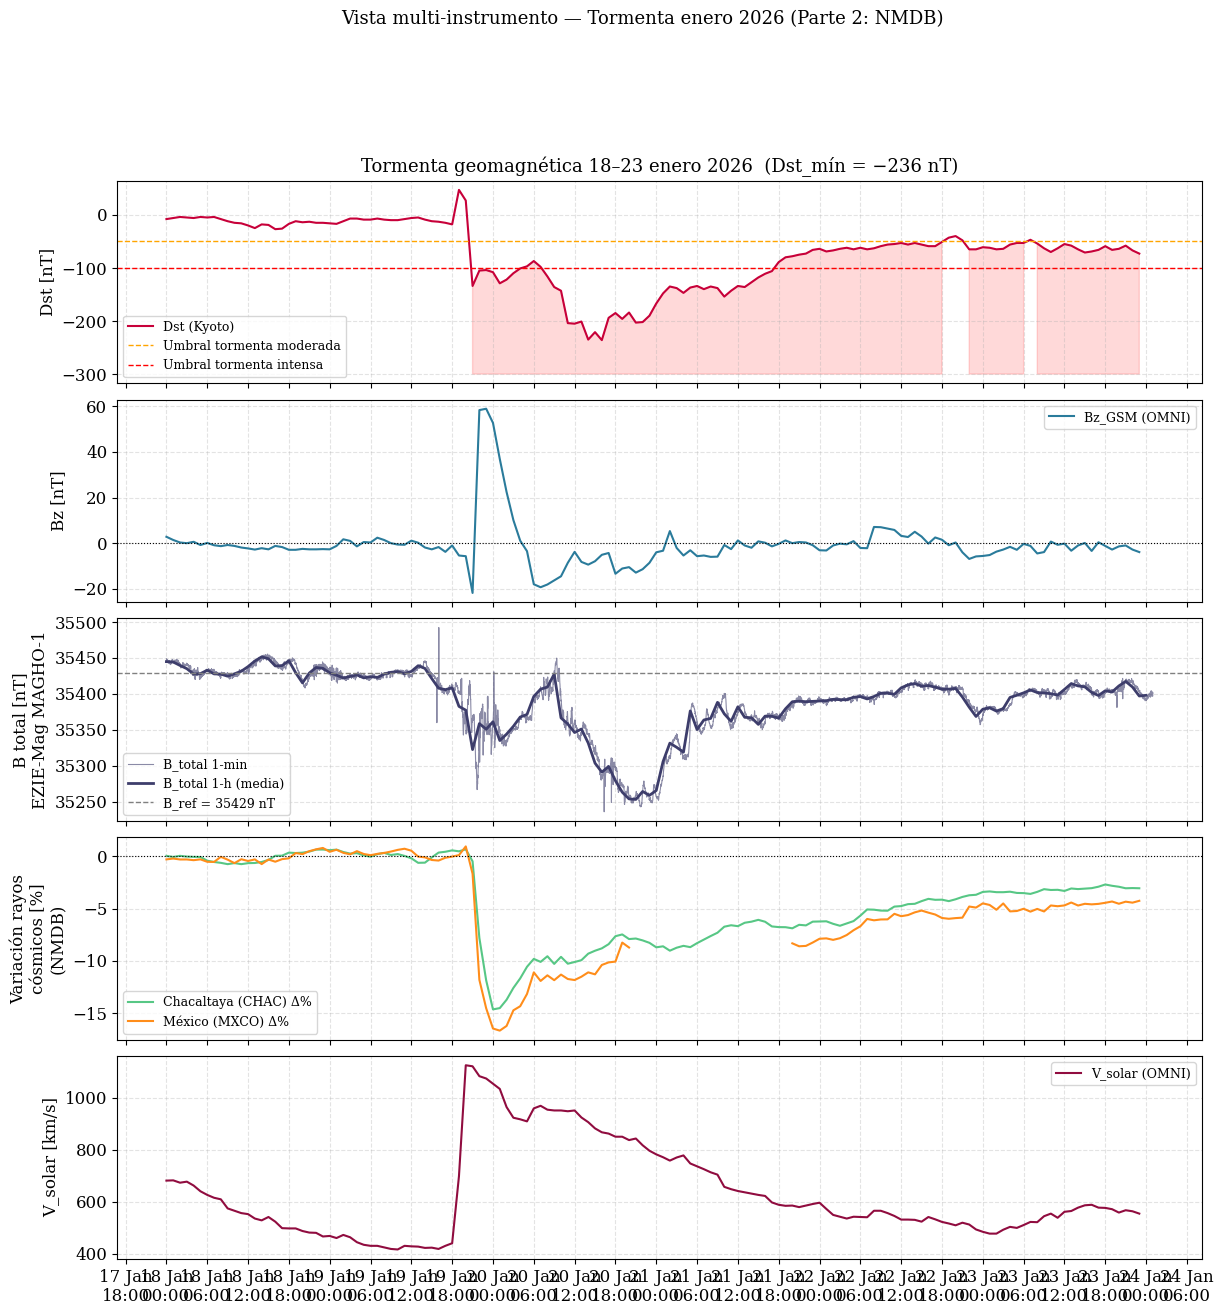

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True,
                          gridspec_kw={'hspace': 0.08})

# ─ Panel 1: Dst ──
t2 = df2.index
axes[0].plot(t2, df2['Dst'], color='#c70039', lw=1.5, label='Dst (Kyoto)')
axes[0].axhline(-50,  color='orange',  ls='--', lw=1, label='Umbral tormenta moderada')
axes[0].axhline(-100, color='red',     ls='--', lw=1, label='Umbral tormenta intensa')
axes[0].fill_between(t2, df2['Dst'], -300, where=df2['Dst'] < -50,
                     alpha=0.15, color='red')
axes[0].set_ylabel('Dst [nT]')
axes[0].legend(fontsize=9, loc='lower left')
axes[0].set_title('Tormenta geomagnética 18–23 enero 2026  (Dst_mín = −236 nT)', fontsize=13)

# ─ Panel 2: Bz solar wind ──
axes[1].plot(t2, df2['Bz_GSM'], color='#2a7b9b', lw=1.5, label='Bz_GSM (OMNI)')
axes[1].axhline(0, color='black', lw=0.8, ls=':')
axes[1].set_ylabel('Bz [nT]')
axes[1].legend(fontsize=9)

# ─ Panel 3: Campo B total (EZIE-Mag) ──
if not df_ezie_storm.empty:
    axes[2].plot(df_ezie_storm.index, df_ezie_storm['B_total_nT'],
                 color='#3d3d6b', lw=0.8, alpha=0.6, label='B_total 1-min')
    axes[2].plot(df_ezie_storm_h.index, df_ezie_storm_h['B_total_nT'],
                 color='#3d3d6b', lw=2, label='B_total 1-h (media)')
    axes[2].axhline(B_ref, color='gray', ls='--', lw=1, label=f'B_ref = {B_ref:.0f} nT')
axes[2].set_ylabel('B total [nT]\nEZIE-Mag MAGHO-1')
axes[2].legend(fontsize=9)

# ─ Panel 4: NMDB México ──
axes[3].plot(df_mxco_h.index, df_mxco_h['MXCO_pct'], color='#ff8d1a', lw=1.5,
             label='México (MXCO) Δ%')
axes[3].axhline(0, color='black', lw=0.8, ls=':')
axes[3].set_ylabel('Variación rayos\ncósmicos [%]\n(NMDB)')
axes[3].legend(fontsize=9)

# ─ Panel 5: Velocidad viento solar ──
axes[4].plot(t2, df2['speed'], color='#900c3f', lw=1.5, label='V_solar (OMNI)')
axes[4].set_ylabel('V_solar [km/s]')
axes[4].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:00'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

plt.suptitle('Vista multi-instrumento — Tormenta enero 2026 (Parte 2: NMDB)', fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig('Fig1_MultiInstrumento_Tormenta.png', dpi=150, bbox_inches='tight')
plt.show()

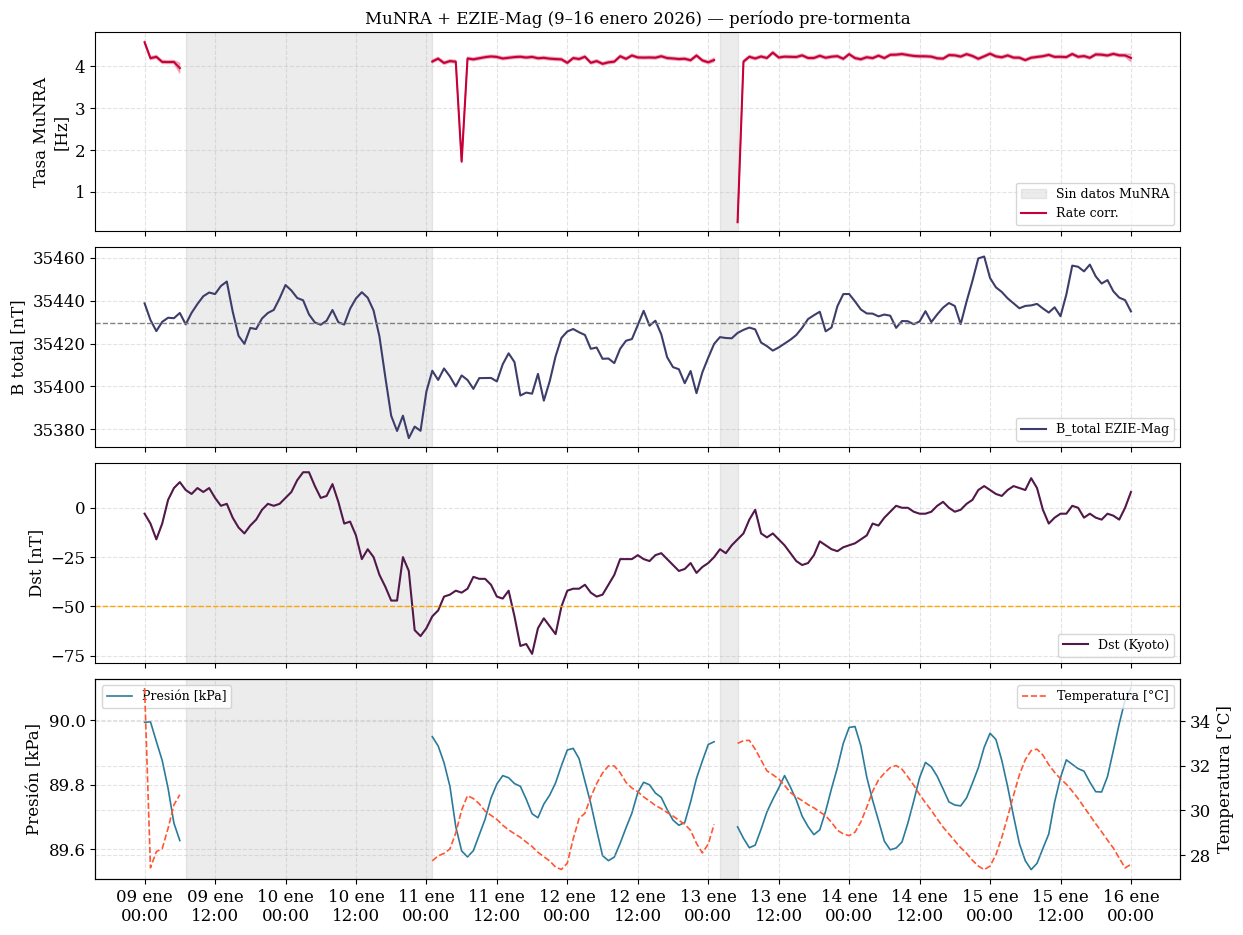

In [ ]:
# ── Vista Parte 1: MuNRA + EZIE + Dst (período pre-tormenta) ─────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True,
                          gridspec_kw={'hspace': 0.08})

t1 = df1.index

# Huecos reales de adquisición de MuNRA (NaN en rate_corr) → sombrear en todos
# los paneles, para no confundirlos con una falla de las otras series.
gap_mask   = df1['rate_corr'].isna()
gap_groups = (gap_mask != gap_mask.shift()).cumsum()
gap_spans  = [
    (grp.index[0], grp.index[-1] + pd.Timedelta(hours=1))
    for _, grp in df1[gap_mask].groupby(gap_groups[gap_mask])
]
for ax in axes:
    for j, (g0, g1) in enumerate(gap_spans):
        ax.axvspan(g0, g1, color='gray', alpha=0.15,
                   label='Sin datos MuNRA' if (ax is axes[0] and j == 0) else None)

axes[0].plot(t1, df1['rate_corr'], color='#c70039', lw=1.5, label='Rate corr.')
axes[0].fill_between(t1,
                     df1['rate_corr'] - df1['rate_err'],
                     df1['rate_corr'] + df1['rate_err'],
                     alpha=0.25, color='#c70039')
axes[0].set_ylabel('Tasa MuNRA\n[Hz]')
axes[0].legend(fontsize=9)
axes[0].set_title('MuNRA + EZIE-Mag (9–16 enero 2026) — período pre-tormenta', fontsize=12)

axes[1].plot(t1, df1['B_total_nT'], color='#3d3d6b', lw=1.5, label='B_total EZIE-Mag')
axes[1].axhline(B_ref, color='gray', ls='--', lw=1)
axes[1].set_ylabel('B total [nT]')
axes[1].legend(fontsize=9)

axes[2].plot(t1, df1['Dst'], color='#511849', lw=1.5, label='Dst (Kyoto)')
axes[2].axhline(-50, color='orange', ls='--', lw=1)
axes[2].set_ylabel('Dst [nT]')
axes[2].legend(fontsize=9)

axes[3].plot(t1, df1['pressure_Pa'] / 1000, color='#2a7b9b', lw=1.2, label='Presión [kPa]')
ax3b = axes[3].twinx()
ax3b.plot(t1, df1['temperature_C'], color='#ff5733', lw=1.2, ls='--', label='Temperatura [°C]')
axes[3].set_ylabel('Presión [kPa]')
ax3b.set_ylabel('Temperatura [°C]')
axes[3].legend(loc='upper left', fontsize=9)
ax3b.legend(loc='upper right', fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d ene\n%H:00'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))

plt.tight_layout()
plt.savefig('Fig2_MultiInstrumento_PreTormenta.png', dpi=150, bbox_inches='tight')
plt.show()

SSC detectado:         10 ene 03:00  Dst = +18 nT
Inicio fase principal: 10 ene 13:00  Dst = -26 nT
Mínimo Dst:            11 ene 18:00  Dst = -74 nT
B_total mínimo:        35375.9 nT  (−53.5 nT vs ref)
B_total máximo:        35460.6 nT  (+31.1 nT vs ref)


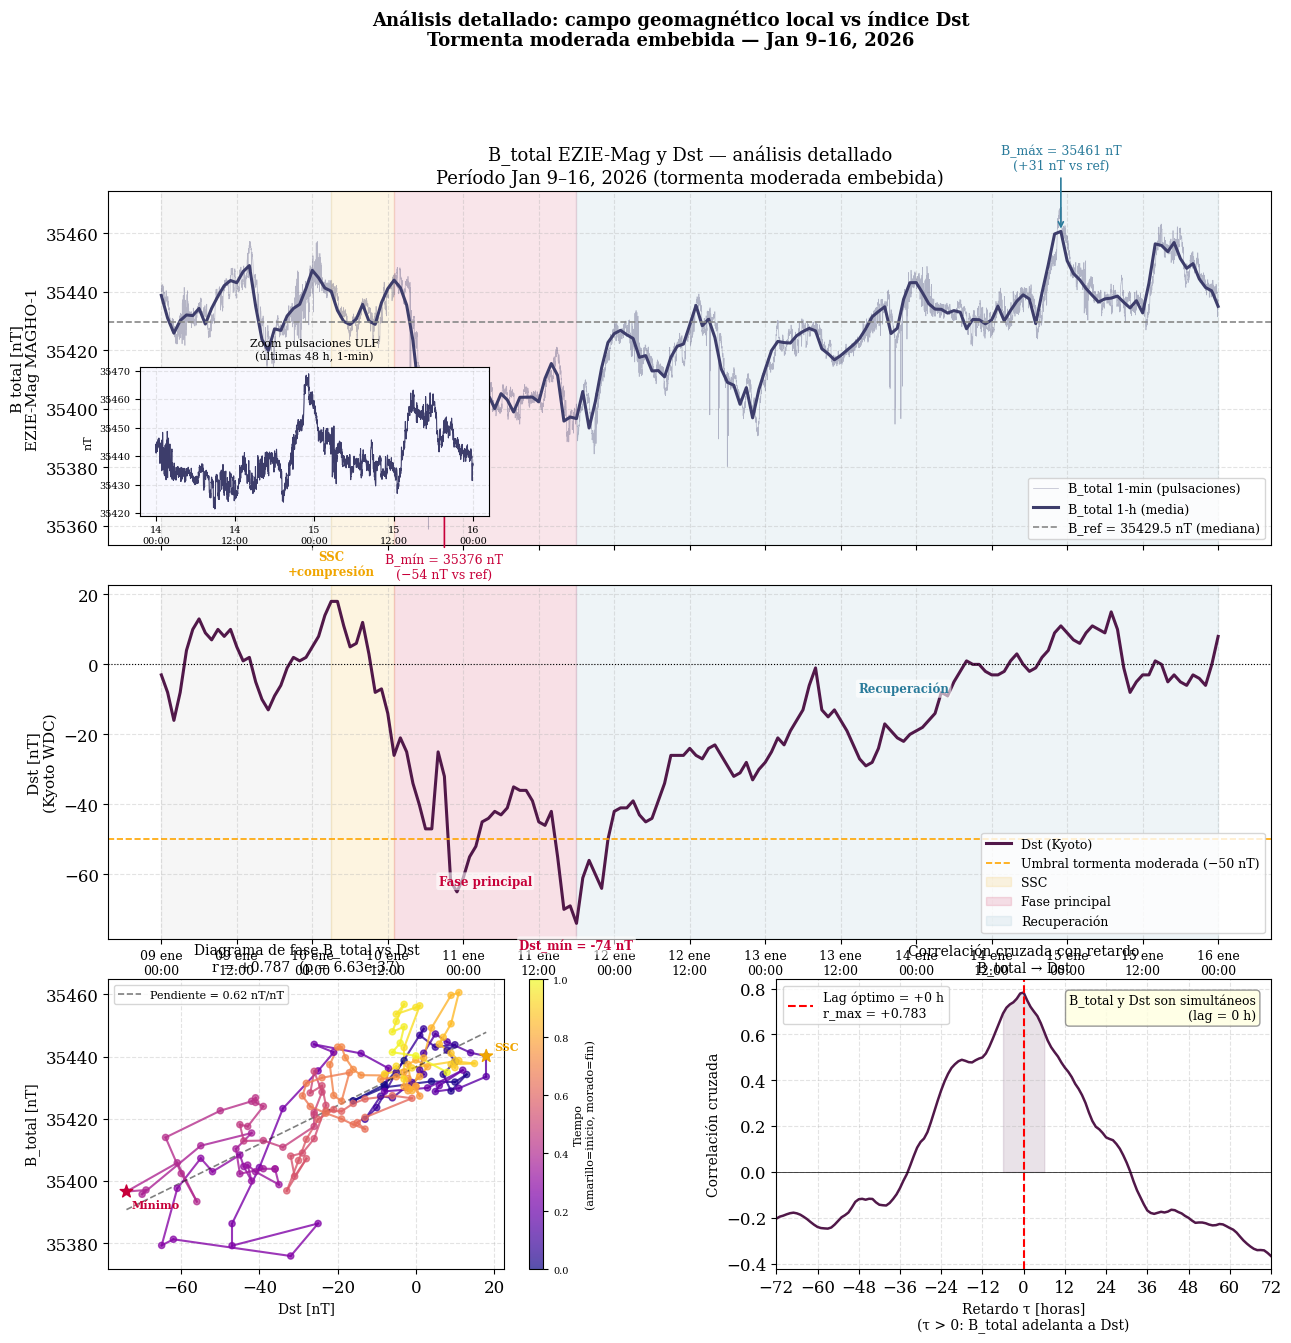


── Resumen cuantitativo ──
  Dst SSC:          +18 nT  (10 ene 03:00)
  Dst mínimo:       -74 nT  (11 ene 18:00)
  ΔDst (SSC→mín):   -92 nT
  B_total mínimo:   35375.9 nT  (−53.5 nT vs ref)
  B_total máximo:   35460.6 nT  (+31.1 nT vs ref)
  r global (B vs Dst): +0.7873  (p = 6.63e-37)
  Lag óptimo:       +0 h  (r_max = +0.783)


In [ ]:
# ── Análisis detallado: B_total EZIE-Mag vs Dst (Jan 9–16) ───────────────────
#
# Estructura: 3 filas
#   [A] B_total 1-min (pulsaciones visibles) + media horaria + anotaciones de fase
#   [B] Dst horario + sombreado por fase + anotaciones clave
#   [C] Scatter B_total vs Dst con colormap de tiempo (trayectoria en espacio de fase)
#   [D] Correlación cruzada con retardo temporal

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.cm as cm

# ── Función auxiliar (también definida en sección 6) ─────────────────────────
def _cross_corr_lag(s1, s2, max_lag_h=72):
    from scipy.signal import correlate
    common = s1.index.intersection(s2.index)
    a = s1.reindex(common).interpolate(limit=6).fillna(s1.mean())
    b = s2.reindex(common).interpolate(limit=6).fillna(s2.mean())
    n = len(a)
    if n < 10:
        return np.array([0]), np.array([0]), 0, 0
    an = (a - a.mean()) / a.std()
    bn = (b - b.mean()) / b.std()
    cc   = correlate(an, bn, mode='full') / n
    lags = np.arange(-(n - 1), n)
    mask = np.abs(lags) <= max_lag_h
    lags_h, cc_m = lags[mask], cc[mask]
    lag_opt = lags_h[np.argmax(np.abs(cc_m))]
    r_max   = cc_m[np.argmax(np.abs(cc_m))]
    return lags_h, cc_m, int(lag_opt), float(r_max)

t1 = df1.index  # índice horario Jan 9–16

# ── Detectar momentos clave automáticamente ───────────────────────────────────
dst_s       = df1['Dst']
ssc_idx     = dst_s.iloc[:len(dst_s)//2].idxmax()
dst_min_idx = dst_s.idxmin()

post_ssc      = dst_s.loc[ssc_idx:]
fp_candidates = post_ssc[post_ssc < -20]
fp_idx  = fp_candidates.index[0] if len(fp_candidates) > 0 else ssc_idx
rec_idx = dst_s.index[min(dst_s.index.get_loc(dst_min_idx) + 2, len(dst_s) - 1)]

dst_ssc_val  = dst_s.loc[ssc_idx]
dst_min_val  = dst_s.min()
btot_min_val = df1['B_total_nT'].min()
btot_max_val = df1['B_total_nT'].max()

print(f'SSC detectado:         {ssc_idx.strftime("%d ene %H:00")}  Dst = {dst_ssc_val:+.0f} nT')
print(f'Inicio fase principal: {fp_idx.strftime("%d ene %H:00")}  Dst = {dst_s.loc[fp_idx]:+.0f} nT')
print(f'Mínimo Dst:            {dst_min_idx.strftime("%d ene %H:00")}  Dst = {dst_min_val:+.0f} nT')
print(f'B_total mínimo:        {btot_min_val:.1f} nT  (−{B_ref - btot_min_val:.1f} nT vs ref)')
print(f'B_total máximo:        {btot_max_val:.1f} nT  (+{btot_max_val - B_ref:.1f} nT vs ref)')

C_SSC   = '#f0a500'
C_MAIN  = '#c70039'
C_REC   = '#2a7b9b'
C_QUIET = '#888888'

fig = plt.figure(figsize=(15, 14))
gs  = fig.add_gridspec(3, 2, height_ratios=[2.2, 2.2, 1.8],
                       hspace=0.12, wspace=0.35)
ax_b   = fig.add_subplot(gs[0, :])
ax_dst = fig.add_subplot(gs[1, :], sharex=ax_b)
ax_sc  = fig.add_subplot(gs[2, 0])
ax_lag = fig.add_subplot(gs[2, 1])

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — B_total
# ─────────────────────────────────────────────────────────────────────────────
if not df_ezie_pre.empty:
    win = df_ezie_pre.loc[MUNRA_CORR_START:MUNRA_CORR_END]
    ax_b.plot(win.index, win['B_total_nT'],
              color='#3d3d6b', lw=0.5, alpha=0.35, label='B_total 1-min (pulsaciones)')

ax_b.plot(t1, df1['B_total_nT'], color='#3d3d6b', lw=2.2, label='B_total 1-h (media)')
ax_b.axhline(B_ref, color='#888888', ls='--', lw=1.2,
             label=f'B_ref = {B_ref:.1f} nT (mediana)')

PHASE_SPANS = [
    (t1[0],       ssc_idx,      C_QUIET, None),
    (ssc_idx,     fp_idx,       C_SSC,   'SSC'),
    (fp_idx,      dst_min_idx,  C_MAIN,  'Fase principal'),
    (dst_min_idx, t1[-1],       C_REC,   'Recuperación'),
]
B_ALPHAS   = [0.07, 0.10, 0.10, 0.08]
DST_ALPHAS = [0.07, 0.12, 0.12, 0.08]
for (t0, t1_, color, _), ab in zip(PHASE_SPANS, B_ALPHAS):
    ax_b.axvspan(t0, t1_, alpha=ab, color=color)

ax_b.annotate(f'B_mín = {btot_min_val:.0f} nT\n(−{B_ref - btot_min_val:.0f} nT vs ref)',
              xy=(df1['B_total_nT'].idxmin(), btot_min_val),
              xytext=(df1['B_total_nT'].idxmin(),
                      btot_min_val - 0.4*(btot_max_val - btot_min_val)),
              fontsize=9, color=C_MAIN, ha='center',
              arrowprops=dict(arrowstyle='->', color=C_MAIN, lw=1.2))
ax_b.annotate(f'B_máx = {btot_max_val:.0f} nT\n(+{btot_max_val - B_ref:.0f} nT vs ref)',
              xy=(df1['B_total_nT'].idxmax(), btot_max_val),
              xytext=(df1['B_total_nT'].idxmax(),
                      btot_max_val + 0.25*(btot_max_val - btot_min_val)),
              fontsize=9, color=C_REC, ha='center',
              arrowprops=dict(arrowstyle='->', color=C_REC, lw=1.2))

ax_b.set_ylabel('B total [nT]\nEZIE-Mag MAGHO-1', fontsize=11)
ax_b.set_title('B_total EZIE-Mag y Dst — análisis detallado\n'
               'Período Jan 9–16, 2026 (tormenta moderada embebida)', fontsize=13)
ax_b.legend(fontsize=9, loc='lower right')

# Inset: zoom pulsaciones ULF (últimas 48 h)
if not df_ezie_pre.empty and len(win) > 10:
    win_puls = win.loc[MUNRA_CORR_END - pd.Timedelta(hours=48):MUNRA_CORR_END]
    if len(win_puls) > 10:
        axins = inset_axes(ax_b, width='30%', height='42%', loc='lower left',
                           bbox_to_anchor=(0.02, 0.06, 1, 1),
                           bbox_transform=ax_b.transAxes)
        axins.plot(win_puls.index, win_puls['B_total_nT'], color='#3d3d6b', lw=0.8)
        axins.set_title('Zoom pulsaciones ULF\n(últimas 48 h, 1-min)', fontsize=8)
        axins.xaxis.set_major_formatter(mdates.DateFormatter('%d\n%H:00'))
        axins.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
        axins.tick_params(labelsize=7)
        axins.set_ylabel('nT', fontsize=8)
        axins.grid(True, alpha=0.3)
        axins.set_facecolor('#f8f8ff')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Dst
# ─────────────────────────────────────────────────────────────────────────────
ax_dst.plot(t1, df1['Dst'], color='#511849', lw=2.2, label='Dst (Kyoto)')
ax_dst.axhline(  0, color='black',  lw=0.8, ls=':')
ax_dst.axhline(-50, color='orange', lw=1.2, ls='--',
               label='Umbral tormenta moderada (−50 nT)')

for (t0, t1_, color, lbl), ad in zip(PHASE_SPANS, DST_ALPHAS):
    ax_dst.axvspan(t0, t1_, alpha=ad, color=color,
                   **(dict(label=lbl) if lbl else {}))

dst_range = dst_min_val - dst_ssc_val
phase_labels = [
    (ssc_idx,
     dst_ssc_val + 0.08 * abs(dst_range),
     'SSC\n+compresión', C_SSC),
    (fp_idx + (dst_min_idx - fp_idx) / 2,
     dst_min_val + 0.12 * abs(dst_range),
     'Fase principal',   C_MAIN),
    (dst_min_idx,
     dst_min_val - 0.08 * abs(dst_range),
     f'Dst_mín = {dst_min_val:.0f} nT', C_MAIN),
    (rec_idx + (t1[-1] - rec_idx) / 2,
     -8,
     'Recuperación',     C_REC),
]
for tx, ty, label, color in phase_labels:
    ax_dst.text(tx, ty, label, fontsize=8.5, color=color, ha='center',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

ax_dst.set_ylabel('Dst [nT]\n(Kyoto WDC)', fontsize=11)
ax_dst.legend(fontsize=9, loc='lower right')

for ax in [ax_b, ax_dst]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d ene\n%H:00'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax.tick_params(axis='x', labelsize=9)
ax_b.tick_params(labelbottom=False)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — Diagrama de fase B_total vs Dst
# ─────────────────────────────────────────────────────────────────────────────
sub   = df1[['B_total_nT', 'Dst']].dropna()
n_pts = len(sub)
cmap_vals = np.linspace(0, 1, n_pts)

for i in range(n_pts - 1):
    ax_sc.plot(sub['Dst'].iloc[i:i+2], sub['B_total_nT'].iloc[i:i+2],
               color=cm.plasma(cmap_vals[i]), lw=1.5, alpha=0.8)
sc = ax_sc.scatter(sub['Dst'], sub['B_total_nT'],
                   c=cmap_vals, cmap='plasma', s=20, zorder=5, alpha=0.7)

c_fit = np.polyfit(sub['Dst'], sub['B_total_nT'], 1)
x_fit = np.linspace(sub['Dst'].min(), sub['Dst'].max(), 50)
ax_sc.plot(x_fit, np.polyval(c_fit, x_fit), 'k--', lw=1.2, alpha=0.5,
           label=f'Pendiente = {c_fit[0]:.2f} nT/nT')

r_sc, p_sc = pearsonr(sub['B_total_nT'], sub['Dst'])
ax_sc.set_xlabel('Dst [nT]', fontsize=10)
ax_sc.set_ylabel('B_total [nT]', fontsize=10)
ax_sc.set_title(f'Diagrama de fase B_total vs Dst\nr = {r_sc:+.3f}  (p = {p_sc:.2e})',
                fontsize=10)
ax_sc.legend(fontsize=8)

cbar = plt.colorbar(sc, ax=ax_sc)
cbar.set_label('Tiempo\n(amarillo=inicio, morado=fin)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

ssc_b = df1.loc[ssc_idx,     'B_total_nT']
ssc_d = df1.loc[ssc_idx,     'Dst']
min_b = df1.loc[dst_min_idx, 'B_total_nT']
min_d = df1.loc[dst_min_idx, 'Dst']
ax_sc.scatter([ssc_d, min_d], [ssc_b, min_b],
              s=90, marker='*', c=[C_SSC, C_MAIN], zorder=10)
ax_sc.annotate('SSC',    (ssc_d, ssc_b), textcoords='offset points',
               xytext=( 6,  4), fontsize=8, color=C_SSC,  fontweight='bold')
ax_sc.annotate('Mínimo', (min_d, min_b), textcoords='offset points',
               xytext=( 4, -12), fontsize=8, color=C_MAIN, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D — Correlación cruzada B_total → Dst
# ─────────────────────────────────────────────────────────────────────────────
lags_cc, cc_vals, lag_opt, r_max = _cross_corr_lag(
    df1['B_total_nT'], df1['Dst'], max_lag_h=72)

ax_lag.plot(lags_cc, cc_vals, color='#511849', lw=1.8)
ax_lag.axvline(lag_opt, color='red', ls='--', lw=1.5,
               label=f'Lag óptimo = {lag_opt:+d} h\nr_max = {r_max:+.3f}')
ax_lag.axhline(0, color='black', lw=0.5)
ax_lag.fill_between(lags_cc, cc_vals, 0,
                    where=(np.abs(lags_cc - lag_opt) <= 6),
                    alpha=0.12, color='#511849')
ax_lag.set_xlabel('Retardo τ [horas]\n(τ > 0: B_total adelanta a Dst)', fontsize=10)
ax_lag.set_ylabel('Correlación cruzada', fontsize=10)
ax_lag.set_title('Correlación cruzada con retardo\nB_total → Dst', fontsize=10)
ax_lag.legend(fontsize=9)
ax_lag.set_xlim(-72, 72)
ax_lag.xaxis.set_major_locator(ticker.MultipleLocator(12))

if lag_opt == 0:
    lag_txt = 'B_total y Dst son simultáneos\n(lag = 0 h)'
elif lag_opt > 0:
    lag_txt = f'B_total adelanta a Dst\nen {lag_opt} h'
else:
    lag_txt = f'Dst adelanta a B_total\nen {abs(lag_opt)} h'
ax_lag.text(0.97, 0.95, lag_txt, transform=ax_lag.transAxes, fontsize=9,
            ha='right', va='top',
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

plt.suptitle('Análisis detallado: campo geomagnético local vs índice Dst\n'
             'Tormenta moderada embebida — Jan 9–16, 2026',
             fontsize=13, y=1.01, fontweight='bold')

plt.tight_layout()
plt.savefig('Fig_Detalle_Btotal_Dst.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Resumen cuantitativo ──')
print(f'  Dst SSC:          {dst_ssc_val:+.0f} nT  ({ssc_idx.strftime("%d ene %H:00")})')
print(f'  Dst mínimo:       {dst_min_val:+.0f} nT  ({dst_min_idx.strftime("%d ene %H:00")})')
print(f'  ΔDst (SSC→mín):   {dst_min_val - dst_ssc_val:.0f} nT')
print(f'  B_total mínimo:   {btot_min_val:.1f} nT  (−{B_ref - btot_min_val:.1f} nT vs ref)')
print(f'  B_total máximo:   {btot_max_val:.1f} nT  (+{btot_max_val - B_ref:.1f} nT vs ref)')
print(f'  r global (B vs Dst): {r_sc:+.4f}  (p = {p_sc:.2e})')
print(f'  Lag óptimo:       {lag_opt:+d} h  (r_max = {r_max:+.3f})')

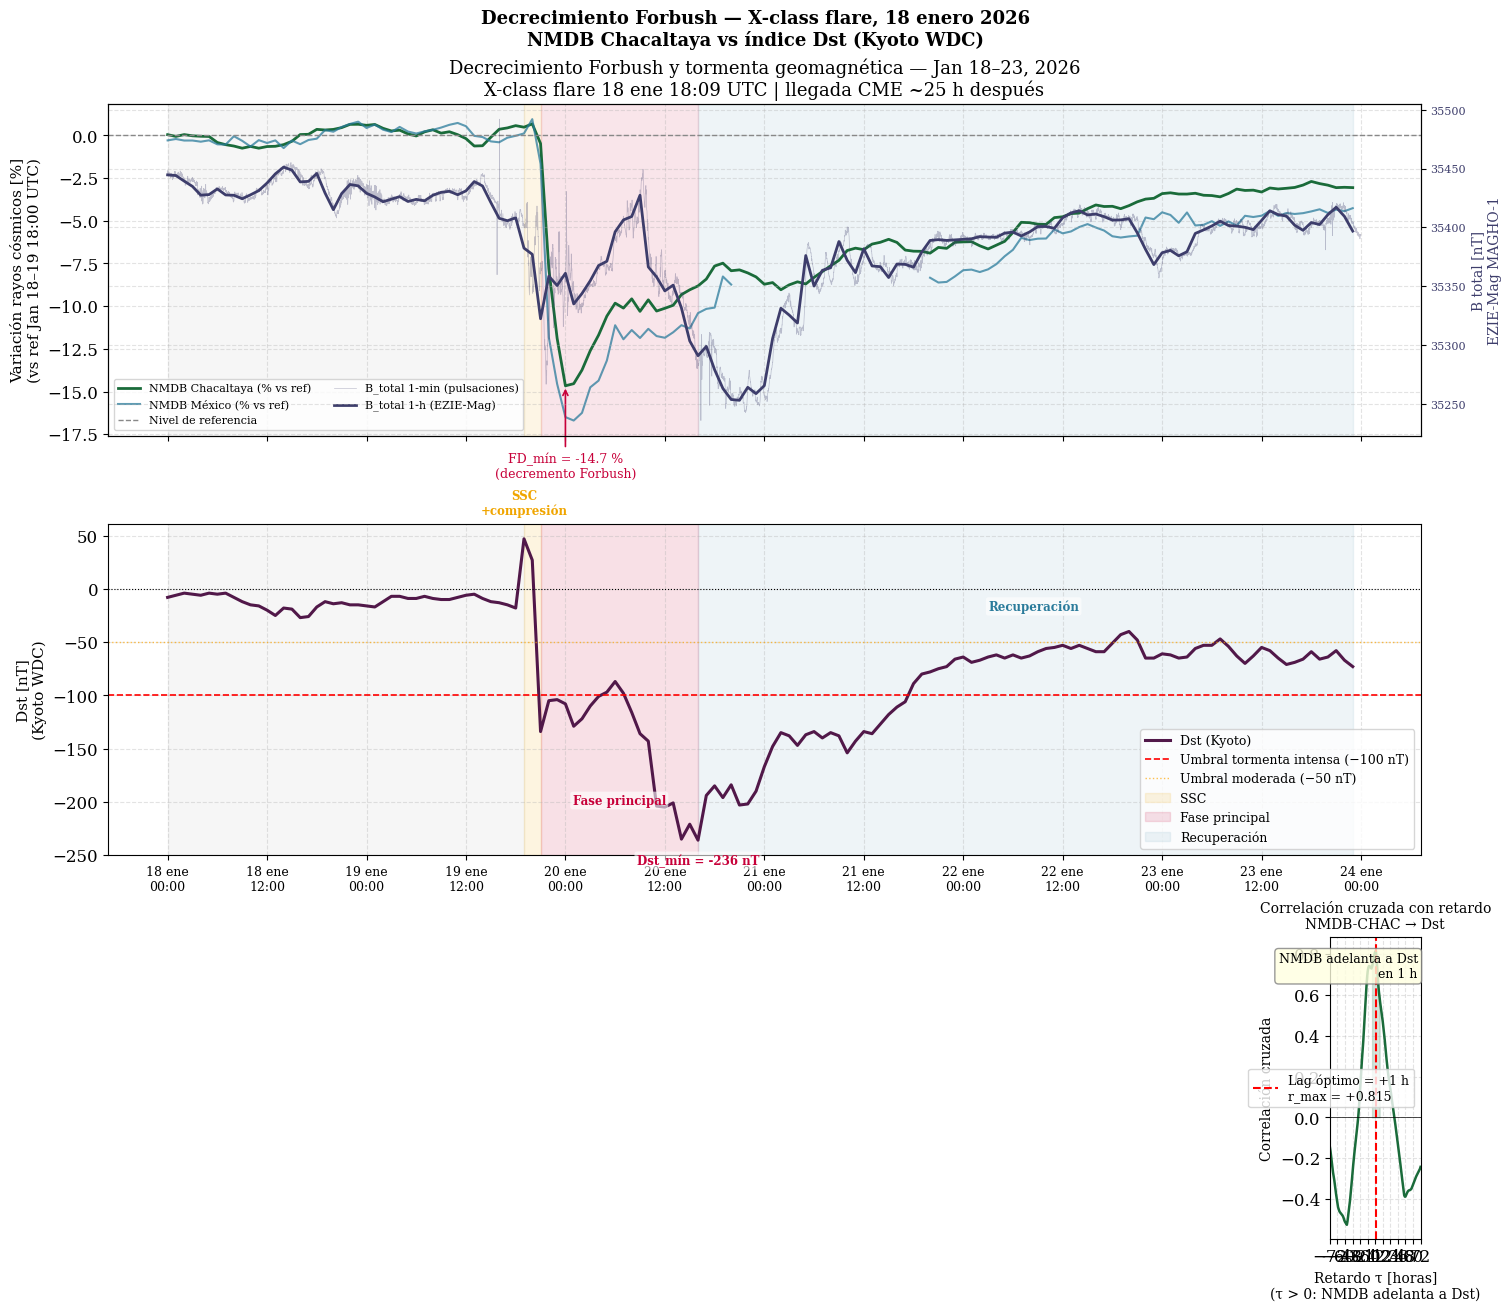


── Resumen cuantitativo (evento principal) ──
  SSC detectado:      19 ene 19:00  Dst = +47 nT
  Dst mínimo:         20 ene 16:00  Dst = -236 nT
  FD mínimo (CHAC):   20 ene 00:00  = -14.66 %
  Lag NMDB→Dst:       +1 h  (r_max = +0.815)


In [ ]:
# ── Figura principal: NMDB + Dst + correlación cruzada (tormenta Jan 18–23) ──
# Panels: [A] NMDB México %  [B] Dst  [D] Cross-corr NMDB→Dst
import matplotlib.ticker as ticker

C_NMDB = '#1a6b3a'
C_DST  = '#511849'

fig2 = plt.figure(figsize=(15, 13), layout="constrained")
gs2  = fig2.add_gridspec(3, 2, height_ratios=[2.2, 2.2, 2.0], wspace=0.35)
ax2_n     = fig2.add_subplot(gs2[0, :])
ax2_dst   = fig2.add_subplot(gs2[1, :], sharex=ax2_n)
ax2_lag   = fig2.add_subplot(gs2[2, 1])
ax2_empty = fig2.add_subplot(gs2[2, 0])
ax2_empty.set_visible(False)

t2 = df2.index

# ── Detección automática de fases (período tormenta) ─────────────────────────
dst_s2       = df2['Dst'].dropna()
ssc_idx2     = dst_s2.iloc[:len(dst_s2)//3].idxmax()
dst_min_idx2 = dst_s2.idxmin()
post_ssc2    = dst_s2.loc[ssc_idx2:]
fp_cands2    = post_ssc2[post_ssc2 < -50]
fp_idx2      = fp_cands2.index[0] if len(fp_cands2) > 0 else ssc_idx2
rec_idx2     = dst_s2.index[min(dst_s2.index.get_loc(dst_min_idx2) + 2, len(dst_s2) - 1)]
dst_ssc_val2 = float(dst_s2.loc[ssc_idx2])
dst_min_val2 = float(dst_s2.min())

mxco_valid   = df2['MXCO_pct'].dropna()
mxco_min_val = float(mxco_valid.min())
mxco_min_idx = mxco_valid.idxmin()
mxco_max_val = float(mxco_valid.max())

PHASE_SPANS2 = [
    (t2[0],        ssc_idx2,      C_QUIET, None),
    (ssc_idx2,     fp_idx2,       C_SSC,   'SSC'),
    (fp_idx2,      dst_min_idx2,  C_MAIN,  'Fase principal'),
    (dst_min_idx2, t2[-1],        C_REC,   'Recuperación'),
]
B_ALPHAS2   = [0.07, 0.10, 0.10, 0.08]
DST_ALPHAS2 = [0.07, 0.12, 0.12, 0.08]

# ─── PANEL A — NMDB ───────────────────────────────────────────────────────────
ax2_n.plot(t2, df2['MXCO_pct'], color=C_NMDB, lw=2.0,
           label='NMDB México (% vs ref)')
ax2_n.axhline(0, color='#888888', ls='--', lw=1.0, label='Nivel de referencia')

for (t0, t1_, color, _), ab in zip(PHASE_SPANS2, B_ALPHAS2):
    ax2_n.axvspan(t0, t1_, alpha=ab, color=color)

# EZIE-Mag B_total en eje secundario
C_BTOT = '#3d3d6b'
ax2_n_r = ax2_n.twinx()
if not df_ezie_storm.empty:
    win_storm = df_ezie_storm.loc[STORM_START:STORM_END]
    ax2_n_r.plot(win_storm.index, win_storm['B_total_nT'],
                 color=C_BTOT, lw=0.5, alpha=0.3,
                 label='B_total 1-min (pulsaciones)')
if 'B_total_nT' in df2.columns:
    ax2_n_r.plot(t2, df2['B_total_nT'],
                 color=C_BTOT, lw=2.0, label='B_total 1-h (EZIE-Mag)')
ax2_n_r.set_ylabel('B total [nT]\nEZIE-Mag MAGHO-1',
                    fontsize=10, color=C_BTOT)
ax2_n_r.tick_params(axis='y', labelcolor=C_BTOT, labelsize=8)

ax2_n.annotate(
    f'FD_mín = {mxco_min_val:.1f} %\n(decremento Forbush)',
    xy=(mxco_min_idx, mxco_min_val),
    xytext=(mxco_min_idx,
            mxco_min_val - 0.35 * abs(mxco_max_val - mxco_min_val)),
    fontsize=9, color=C_MAIN, ha='center',
    arrowprops=dict(arrowstyle='->', color=C_MAIN, lw=1.2))

ax2_n.set_ylabel('Variación rayos cósmicos [%]\n(vs ref Jan 18–19 18:00 UTC)', fontsize=11)
ax2_n.set_title(
    'Decrecimiento Forbush y tormenta geomagnética — Jan 18–23, 2026',
    fontsize=13)
handles_n, labels_n   = ax2_n.get_legend_handles_labels()
handles_r, labels_r   = ax2_n_r.get_legend_handles_labels()
ax2_n.legend(handles_n + handles_r, labels_n + labels_r,
             fontsize=8, loc='lower left', ncol=2)

# ─── PANEL B — Dst ────────────────────────────────────────────────────────────
ax2_dst.plot(t2, df2['Dst'], color=C_DST, lw=2.2, label='Dst (Kyoto)')
ax2_dst.axhline(   0, color='black',   lw=0.8, ls=':')
ax2_dst.axhline(-100, color='red',     lw=1.2, ls='--',
                label='Umbral tormenta intensa (−100 nT)')
ax2_dst.axhline( -50, color='orange',  lw=1.0, ls=':', alpha=0.7,
                label='Umbral moderada (−50 nT)')

for (t0, t1_, color, lbl), ad in zip(PHASE_SPANS2, DST_ALPHAS2):
    ax2_dst.axvspan(t0, t1_, alpha=ad, color=color,
                    **(dict(label=lbl) if lbl else {}))

dst_range2 = dst_min_val2 - dst_ssc_val2
for tx, ty, lbl, color in [
    (ssc_idx2,
     dst_ssc_val2 + 0.08 * abs(dst_range2), 'SSC\n+compresión', C_SSC),
    (fp_idx2 + (dst_min_idx2 - fp_idx2) / 2,
     dst_min_val2 + 0.12 * abs(dst_range2), 'Fase principal',    C_MAIN),
    (dst_min_idx2,
     dst_min_val2 - 0.08 * abs(dst_range2),
     f'Dst_mín = {dst_min_val2:.0f} nT',                         C_MAIN),
    (rec_idx2 + (t2[-1] - rec_idx2) / 2,
     -20, 'Recuperación',                                         C_REC),
]:
    ax2_dst.text(tx, ty, lbl, fontsize=8.5, color=color, ha='center',
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

ax2_dst.set_ylabel('Dst [nT]\n(Kyoto WDC)', fontsize=11)
ax2_dst.legend(fontsize=9, loc='lower right')

for ax in [ax2_n, ax2_dst]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d ene\n%H:00'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax.tick_params(axis='x', labelsize=9)
ax2_n.tick_params(labelbottom=False)

# ─── PANEL D — Correlación cruzada NMDB → Dst ────────────────────────────────
lags_cc2, cc_vals2, lag_opt2, r_max2 = _cross_corr_lag(
    df2['MXCO_pct'], df2['Dst'], max_lag_h=72)

ax2_lag.plot(lags_cc2, cc_vals2, color=C_NMDB, lw=1.8)
ax2_lag.axvline(lag_opt2, color='red', ls='--', lw=1.5,
                label=f'Lag óptimo = {lag_opt2:+d} h\nr_max = {r_max2:+.3f}')
ax2_lag.axhline(0, color='black', lw=0.5)
ax2_lag.fill_between(lags_cc2, cc_vals2, 0,
                     where=(np.abs(lags_cc2 - lag_opt2) <= 6),
                     alpha=0.18, color=C_NMDB)
ax2_lag.set_xlabel('Retardo τ [horas]\n(τ > 0: NMDB adelanta a Dst)', fontsize=10)
ax2_lag.set_ylabel('Correlación cruzada', fontsize=10)
ax2_lag.set_title('Correlación cruzada con retardo\nNMDB-MXCO → Dst', fontsize=10)
ax2_lag.legend(fontsize=9)
ax2_lag.set_xlim(-72, 72)
ax2_lag.xaxis.set_major_locator(ticker.MultipleLocator(12))

if lag_opt2 == 0:
    lag_txt2 = 'NMDB y Dst son simultáneos\n(lag = 0 h)'
elif lag_opt2 > 0:
    lag_txt2 = f'NMDB adelanta a Dst\nen {lag_opt2} h'
else:
    lag_txt2 = f'Dst adelanta a NMDB\nen {abs(lag_opt2)} h'
ax2_lag.text(0.97, 0.95, lag_txt2, transform=ax2_lag.transAxes, fontsize=9,
             ha='right', va='top',
             bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

plt.suptitle('Decrecimiento Forbush — 18 enero 2026\n'
             'NMDB México (MXCO) vs índice Dst (Kyoto WDC)',
             fontsize=13, fontweight='bold')

plt.savefig('Fig_Detalle_NMDB_Dst_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Resumen cuantitativo (evento principal) ──')
print(f'  SSC detectado:      {ssc_idx2.strftime("%d ene %H:00")}  Dst = {dst_ssc_val2:+.0f} nT')
print(f'  Dst mínimo:         {dst_min_idx2.strftime("%d ene %H:00")}  Dst = {dst_min_val2:+.0f} nT')
print(f'  FD mínimo (MXCO):   {mxco_min_idx.strftime("%d ene %H:00")}  = {mxco_min_val:.2f} %')
print(f'  Lag NMDB→Dst:       {lag_opt2:+d} h  (r_max = {r_max2:+.3f})')


SSC detectado:         19 ene 19:00  Dst = +47 nT
Inicio fase principal: 19 ene 21:00  Dst = -134 nT
Mínimo Dst:            20 ene 16:00  Dst = -236 nT
B_total mínimo:        35253.0 nT  (−176.4 nT vs ref)
B_total máximo:        35451.4 nT  (+21.9 nT vs ref)


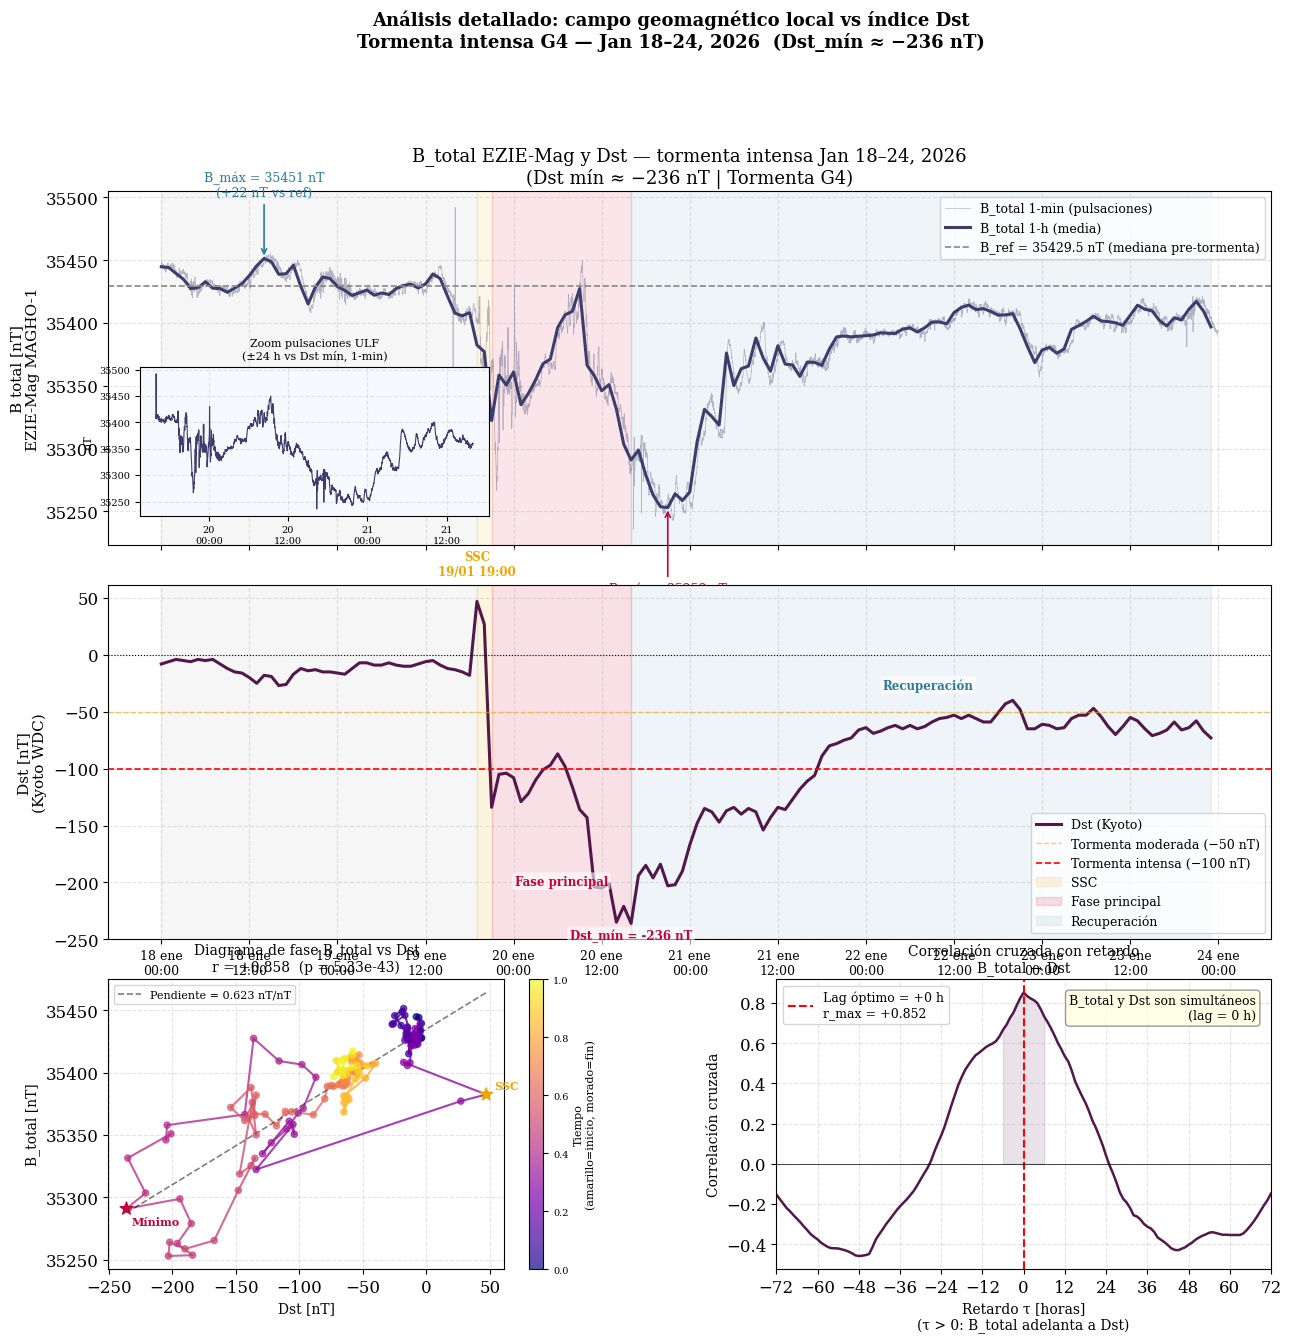


── Resumen cuantitativo — Tormenta Jan 18–24 ──
  Dst SSC:          +47 nT  (19 ene 19:00)
  Dst mínimo:       -236 nT  (20 ene 16:00)
  ΔDst (SSC→mín):   -283 nT
  B_total mínimo:   35253.0 nT  (−176.4 nT vs ref)
  B_total máximo:   35451.4 nT  (+21.9 nT vs ref)
  r global (B vs Dst): +0.8584  (p = 5.33e-43)
  Lag óptimo:       +0 h  (r_max = +0.852)


In [ ]:
# ── Análisis detallado: B_total EZIE-Mag vs Dst (Jan 18–24, tormenta real) ────
#
# Estructura: 3 filas
#   [A] B_total 1-min (pulsaciones visibles) + media horaria + anotaciones de fase
#   [B] Dst horario + sombreado por fase + anotaciones clave
#   [C] Scatter B_total vs Dst con colormap de tiempo (trayectoria en espacio de fase)
#   [D] Correlación cruzada con retardo temporal

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from scipy.stats import pearsonr

def _cross_corr_lag(s1, s2, max_lag_h=72):
    from scipy.signal import correlate
    common = s1.index.intersection(s2.index)
    a = s1.reindex(common).interpolate(limit=6).fillna(s1.mean())
    b = s2.reindex(common).interpolate(limit=6).fillna(s2.mean())
    n = len(a)
    if n < 10:
        return np.array([0]), np.array([0]), 0, 0
    an = (a - a.mean()) / (a.std() or 1)
    bn = (b - b.mean()) / (b.std() or 1)
    cc   = correlate(an, bn, mode='full') / n
    lags = np.arange(-(n - 1), n)
    mask = np.abs(lags) <= max_lag_h
    lags_h, cc_m = lags[mask], cc[mask]
    lag_opt = lags_h[np.argmax(np.abs(cc_m))]
    r_max   = cc_m[np.argmax(np.abs(cc_m))]
    return lags_h, cc_m, int(lag_opt), float(r_max)

# ── Dataset: df2 tiene B_total_nT y Dst para el período de tormenta ──────────
t2 = df2.index   # índice horario Jan 18–24

# ── Detectar momentos clave automáticamente ───────────────────────────────────
dst_s       = df2['Dst'].dropna()
# SSC: máximo Dst en el primer tercio (compresión magnetosférica)
ssc_idx     = dst_s.iloc[:len(dst_s)//3].idxmax()
dst_min_idx = dst_s.idxmin()

post_ssc      = dst_s.loc[ssc_idx:]
fp_candidates = post_ssc[post_ssc < -100]   # umbral tormenta intensa
fp_idx  = fp_candidates.index[0] if len(fp_candidates) > 0 else ssc_idx
rec_idx = dst_s.index[min(dst_s.index.get_loc(dst_min_idx) + 2, len(dst_s) - 1)]

dst_ssc_val  = float(dst_s.loc[ssc_idx])
dst_min_val  = float(dst_s.min())

# B_total del período de tormenta (df2 ya tiene media horaria)
btot_series  = df2['B_total_nT'].dropna()
btot_min_val = float(btot_series.min())
btot_max_val = float(btot_series.max())
# B_ref ya definida en celda de carga (mediana pre-tormenta Jan 9-16)

print(f'SSC detectado:         {ssc_idx.strftime("%d ene %H:00")}  Dst = {dst_ssc_val:+.0f} nT')
print(f'Inicio fase principal: {fp_idx.strftime("%d ene %H:00")}  Dst = {dst_s.loc[fp_idx]:+.0f} nT')
print(f'Mínimo Dst:            {dst_min_idx.strftime("%d ene %H:00")}  Dst = {dst_min_val:+.0f} nT')
print(f'B_total mínimo:        {btot_min_val:.1f} nT  (−{B_ref - btot_min_val:.1f} nT vs ref)')
print(f'B_total máximo:        {btot_max_val:.1f} nT  (+{btot_max_val - B_ref:.1f} nT vs ref)')

C_SSC   = '#f0a500'
C_MAIN  = '#c70039'
C_REC   = '#2a7b9b'
C_QUIET = '#888888'

fig = plt.figure(figsize=(15, 14))
gs  = fig.add_gridspec(3, 2, height_ratios=[2.2, 2.2, 1.8],
                       hspace=0.12, wspace=0.35)
ax_b   = fig.add_subplot(gs[0, :])
ax_dst = fig.add_subplot(gs[1, :], sharex=ax_b)
ax_sc  = fig.add_subplot(gs[2, 0])
ax_lag = fig.add_subplot(gs[2, 1])

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — B_total
# ─────────────────────────────────────────────────────────────────────────────
# Pulsaciones a 1-min (fondo)
if not df_ezie_storm.empty:
    win1min = df_ezie_storm.loc[STORM_START:STORM_END]
    ax_b.plot(win1min.index, win1min['B_total_nT'],
              color='#3d3d6b', lw=0.5, alpha=0.35, label='B_total 1-min (pulsaciones)')

# Media horaria (df2)
ax_b.plot(t2, df2['B_total_nT'], color='#3d3d6b', lw=2.2, label='B_total 1-h (media)')
ax_b.axhline(B_ref, color='#888888', ls='--', lw=1.2,
             label=f'B_ref = {B_ref:.1f} nT (mediana pre-tormenta)')

PHASE_SPANS = [
    (t2[0],       ssc_idx,      C_QUIET, None),
    (ssc_idx,     fp_idx,       C_SSC,   'SSC'),
    (fp_idx,      dst_min_idx,  C_MAIN,  'Fase principal'),
    (dst_min_idx, t2[-1],       C_REC,   'Recuperación'),
]
B_ALPHAS   = [0.07, 0.10, 0.10, 0.08]
DST_ALPHAS = [0.07, 0.12, 0.12, 0.08]
for (t0, t1_, color, _), ab in zip(PHASE_SPANS, B_ALPHAS):
    ax_b.axvspan(t0, t1_, alpha=ab, color=color)

if not btot_series.empty:
    ax_b.annotate(f'B_mín = {btot_min_val:.0f} nT\n(−{B_ref - btot_min_val:.0f} nT vs ref)',
                  xy=(btot_series.idxmin(), btot_min_val),
                  xytext=(btot_series.idxmin(),
                          btot_min_val - 0.4*(btot_max_val - btot_min_val)),
                  fontsize=9, color=C_MAIN, ha='center',
                  arrowprops=dict(arrowstyle='->', color=C_MAIN, lw=1.2))
    ax_b.annotate(f'B_máx = {btot_max_val:.0f} nT\n(+{btot_max_val - B_ref:.0f} nT vs ref)',
                  xy=(btot_series.idxmax(), btot_max_val),
                  xytext=(btot_series.idxmax(),
                          btot_max_val + 0.25*(btot_max_val - btot_min_val)),
                  fontsize=9, color=C_REC, ha='center',
                  arrowprops=dict(arrowstyle='->', color=C_REC, lw=1.2))

ax_b.set_ylabel('B total [nT]\nEZIE-Mag MAGHO-1', fontsize=11)
ax_b.set_title('B_total EZIE-Mag y Dst — tormenta intensa Jan 18–24, 2026\n'
               '(Dst mín ≈ −236 nT | Tormenta G4)', fontsize=13)
ax_b.legend(fontsize=9, loc='upper right')

# Inset: zoom pulsaciones ULF (48 h en torno al mínimo Dst)
if not df_ezie_storm.empty and len(win1min) > 10:
    zoom_start = dst_min_idx - pd.Timedelta(hours=24)
    zoom_end   = dst_min_idx + pd.Timedelta(hours=24)
    win_puls   = win1min.loc[zoom_start:zoom_end]
    if len(win_puls) > 10:
        axins = inset_axes(ax_b, width='30%', height='42%', loc='lower left',
                           bbox_to_anchor=(0.02, 0.06, 1, 1),
                           bbox_transform=ax_b.transAxes)
        axins.plot(win_puls.index, win_puls['B_total_nT'], color='#3d3d6b', lw=0.8)
        axins.set_title('Zoom pulsaciones ULF\n(±24 h vs Dst mín, 1-min)', fontsize=8)
        axins.xaxis.set_major_formatter(mdates.DateFormatter('%d\n%H:00'))
        axins.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
        axins.tick_params(labelsize=7)
        axins.set_ylabel('nT', fontsize=8)
        axins.grid(True, alpha=0.3)
        axins.set_facecolor('#f8f8ff')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Dst
# ─────────────────────────────────────────────────────────────────────────────
ax_dst.plot(t2, df2['Dst'], color='#511849', lw=2.2, label='Dst (Kyoto)')
ax_dst.axhline(   0, color='black',  lw=0.8, ls=':')
ax_dst.axhline( -50, color='orange', lw=1.0, ls='--', alpha=0.6,
               label='Tormenta moderada (−50 nT)')
ax_dst.axhline(-100, color='red',    lw=1.2, ls='--',
               label='Tormenta intensa (−100 nT)')

for (t0, t1_, color, lbl), ad in zip(PHASE_SPANS, DST_ALPHAS):
    ax_dst.axvspan(t0, t1_, alpha=ad, color=color,
                   **(dict(label=lbl) if lbl else {}))

dst_range = dst_min_val - dst_ssc_val
phase_labels = [
    (ssc_idx,
     dst_ssc_val + 0.08 * abs(dst_range),
     f'SSC\n{ssc_idx.strftime("%d/%m %H:00")}', C_SSC),
    (fp_idx + (dst_min_idx - fp_idx) / 2,
     dst_min_val + 0.12 * abs(dst_range),
     'Fase principal',   C_MAIN),
    (dst_min_idx,
     dst_min_val - 0.05 * abs(dst_range),
     f'Dst_mín = {dst_min_val:.0f} nT', C_MAIN),
    (rec_idx + (t2[-1] - rec_idx) / 2,
     -30,
     'Recuperación',     C_REC),
]
for tx, ty, label, color in phase_labels:
    ax_dst.text(tx, ty, label, fontsize=8.5, color=color, ha='center',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

ax_dst.set_ylabel('Dst [nT]\n(Kyoto WDC)', fontsize=11)
ax_dst.legend(fontsize=9, loc='lower right')

for ax in [ax_b, ax_dst]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d ene\n%H:00'))
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax.tick_params(axis='x', labelsize=9)
ax_b.tick_params(labelbottom=False)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — Diagrama de fase B_total vs Dst
# ─────────────────────────────────────────────────────────────────────────────
sub   = df2[['B_total_nT', 'Dst']].dropna()
n_pts = len(sub)
if n_pts >= 3:
    cmap_vals = np.linspace(0, 1, n_pts)

    for i in range(n_pts - 1):
        ax_sc.plot(sub['Dst'].iloc[i:i+2], sub['B_total_nT'].iloc[i:i+2],
                   color=cm.plasma(cmap_vals[i]), lw=1.5, alpha=0.8)
    sc = ax_sc.scatter(sub['Dst'], sub['B_total_nT'],
                       c=cmap_vals, cmap='plasma', s=20, zorder=5, alpha=0.7)

    c_fit = np.polyfit(sub['Dst'], sub['B_total_nT'], 1)
    x_fit = np.linspace(sub['Dst'].min(), sub['Dst'].max(), 50)
    ax_sc.plot(x_fit, np.polyval(c_fit, x_fit), 'k--', lw=1.2, alpha=0.5,
               label=f'Pendiente = {c_fit[0]:.3f} nT/nT')

    r_sc, p_sc = pearsonr(sub['B_total_nT'], sub['Dst'])
    ax_sc.set_xlabel('Dst [nT]', fontsize=10)
    ax_sc.set_ylabel('B_total [nT]', fontsize=10)
    ax_sc.set_title(f'Diagrama de fase B_total vs Dst\nr = {r_sc:+.3f}  (p = {p_sc:.2e})',
                    fontsize=10)
    ax_sc.legend(fontsize=8)

    cbar = plt.colorbar(sc, ax=ax_sc)
    cbar.set_label('Tiempo\n(amarillo=inicio, morado=fin)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    # Marcar SSC y mínimo
    if ssc_idx in sub.index and dst_min_idx in sub.index:
        ssc_b = sub.loc[ssc_idx, 'B_total_nT']
        ssc_d = sub.loc[ssc_idx, 'Dst']
        min_b = sub.loc[dst_min_idx, 'B_total_nT']
        min_d = sub.loc[dst_min_idx, 'Dst']
        ax_sc.scatter([ssc_d, min_d], [ssc_b, min_b],
                      s=90, marker='*', c=[C_SSC, C_MAIN], zorder=10)
        ax_sc.annotate('SSC',    (ssc_d, ssc_b), textcoords='offset points',
                       xytext=( 6,  4), fontsize=8, color=C_SSC,  fontweight='bold')
        ax_sc.annotate('Mínimo', (min_d, min_b), textcoords='offset points',
                       xytext=( 4, -12), fontsize=8, color=C_MAIN, fontweight='bold')
else:
    ax_sc.text(0.5, 0.5, 'Datos EZIE-Mag insuficientes\npara diagrama de fase',
               transform=ax_sc.transAxes, ha='center', va='center', fontsize=10)
    r_sc, p_sc = float('nan'), float('nan')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D — Correlación cruzada B_total → Dst
# ─────────────────────────────────────────────────────────────────────────────
lags_cc, cc_vals, lag_opt, r_max = _cross_corr_lag(
    df2['B_total_nT'], df2['Dst'], max_lag_h=72)

ax_lag.plot(lags_cc, cc_vals, color='#511849', lw=1.8)
ax_lag.axvline(lag_opt, color='red', ls='--', lw=1.5,
               label=f'Lag óptimo = {lag_opt:+d} h\nr_max = {r_max:+.3f}')
ax_lag.axhline(0, color='black', lw=0.5)
ax_lag.fill_between(lags_cc, cc_vals, 0,
                    where=(np.abs(lags_cc - lag_opt) <= 6),
                    alpha=0.12, color='#511849')
ax_lag.set_xlabel('Retardo τ [horas]\n(τ > 0: B_total adelanta a Dst)', fontsize=10)
ax_lag.set_ylabel('Correlación cruzada', fontsize=10)
ax_lag.set_title('Correlación cruzada con retardo\nB_total → Dst', fontsize=10)
ax_lag.legend(fontsize=9)
ax_lag.set_xlim(-72, 72)
ax_lag.xaxis.set_major_locator(ticker.MultipleLocator(12))

if lag_opt == 0:
    lag_txt = 'B_total y Dst son simultáneos\n(lag = 0 h)'
elif lag_opt > 0:
    lag_txt = f'B_total adelanta a Dst\nen {lag_opt} h'
else:
    lag_txt = f'Dst adelanta a B_total\nen {abs(lag_opt)} h'
ax_lag.text(0.97, 0.95, lag_txt, transform=ax_lag.transAxes, fontsize=9,
            ha='right', va='top',
            bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

plt.suptitle('Análisis detallado: campo geomagnético local vs índice Dst\n'
             'Tormenta intensa G4 — Jan 18–24, 2026  (Dst_mín ≈ −236 nT)',
             fontsize=13, y=1.01, fontweight='bold')

plt.tight_layout()
plt.savefig('Fig_Detalle_Btotal_Dst_tormenta.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Resumen cuantitativo — Tormenta Jan 18–24 ──')
print(f'  Dst SSC:          {dst_ssc_val:+.0f} nT  ({ssc_idx.strftime("%d ene %H:00")})')
print(f'  Dst mínimo:       {dst_min_val:+.0f} nT  ({dst_min_idx.strftime("%d ene %H:00")})')
print(f'  ΔDst (SSC→mín):   {dst_min_val - dst_ssc_val:.0f} nT')
print(f'  B_total mínimo:   {btot_min_val:.1f} nT  (−{B_ref - btot_min_val:.1f} nT vs ref)')
print(f'  B_total máximo:   {btot_max_val:.1f} nT  (+{btot_max_val - B_ref:.1f} nT vs ref)')
if not np.isnan(r_sc):
    print(f'  r global (B vs Dst): {r_sc:+.4f}  (p = {p_sc:.2e})')
print(f'  Lag óptimo:       {lag_opt:+d} h  (r_max = {r_max:+.3f})')


## 5. Correlaciones de Pearson

Metodología: Castillo Rosales (2017), pp. 63–67.  
Para cada par de series se calcula:
- **r global**: Pearson sobre toda la serie
- **r₀**: transformada de Fisher inversa de z̄ = atanh(r)
- Significativo si |r| > 0.403 (n=24, α=5%)

In [ ]:
# ── Pearson global y Fisher ───────────────────────────────────────────────────
def fisher_r0(r_series):
    """Calcula r₀ = tanh(z̄) y otras estadísticas de la distribución de r."""
    r_vals = np.clip(r_series.dropna().values, -0.9999, 0.9999)
    z_vals = 0.5 * np.log((1 + r_vals) / (1 - r_vals))
    z_mean = z_vals.mean()
    return {
        'r_mean': r_vals.mean(),
        'r0':     np.tanh(z_mean),
        'z_mean': z_mean,
        'z_std':  z_vals.std(),
        'N':      len(r_vals),
        'N_sig':  (np.abs(r_vals) >= R_THRESHOLD).sum()
    }


def pearson_daily(s_a, s_b, min_pts=20):
    """r de Pearson día a día (tesis pp. 89-97)."""
    r_vals, dates = [], []
    for day, grp_a in s_a.resample('1D'):
        grp_b = s_b.reindex(grp_a.index)
        mask  = grp_a.notna() & grp_b.notna()
        if mask.sum() >= min_pts:
            r, _ = pearsonr(grp_a[mask], grp_b[mask])
            r_vals.append(r); dates.append(day)
    return pd.Series(r_vals, index=dates, name='r')


# ── Correlaciones Parte 1 (MuNRA vs EZIE-Mag, Dst, P, T) ─────────────────────
pairs_p1 = [
    ('MuNRA vs B_total (EZIE)',   'rate_corr', 'B_total_nT'),
    ('MuNRA vs ΔB (EZIE)',        'rate_corr', 'delta_B_nT'),
    ('MuNRA vs Dst',              'rate_corr', 'Dst'),
    ('MuNRA vs Presión',          'rate_corr', 'pressure_Pa'),
    ('MuNRA vs Temperatura',      'rate_corr', 'temperature_C'),
    ('B_total vs Dst',            'B_total_nT','Dst'),
]

rows = []
for label, ca, cb in pairs_p1:
    sub = df1[[ca, cb]].dropna()
    if len(sub) < 5:
        continue
    r_g, p_g = pearsonr(sub[ca], sub[cb])
    r_d = pearson_daily(df1[ca], df1[cb])
    fs  = fisher_r0(r_d)
    rows.append({
        'Par':          label,
        'r global':     f'{r_g:+.4f}',
        'p-value':      f'{p_g:.2e}',
        'Sig. global':  '✓' if abs(r_g) >= R_THRESHOLD else '✗',
        'r₀ (Fisher)':  f'{fs["r0"]:+.4f}',
        'N días':       fs['N'],
        'N sig':        fs['N_sig'],
    })

df_corr1 = pd.DataFrame(rows)
print('=== PARTE 1 (MuNRA + EZIE-Mag, Jan 9–16) ===')
display(df_corr1)

=== PARTE 1 (MuNRA + EZIE-Mag, Jan 9–16) ===


,Par,r global,p-value,Sig. global,r₀ (Fisher),N días,N sig
0,MuNRA vs B_total (EZIE),+0.1250,1.66e-01,✗,+0.0718,5,0
1,MuNRA vs ΔB (EZIE),+0.1250,1.66e-01,✗,+0.0718,5,0
2,MuNRA vs Dst,+0.0887,3.27e-01,✗,+0.0414,5,2
3,MuNRA vs Presión,+0.1635,6.97e-02,✗,+0.1870,5,1
4,MuNRA vs Temperatura,-0.1177,1.93e-01,✗,-0.2128,5,1
5,B_total vs Dst,+0.7873,6.63e-37,✓,+0.2967,7,2


In [ ]:
# ── Correlaciones Parte 2 (NMDB vs EZIE-Mag, Dst — tormenta) ─────────────────
pairs_p2 = [
    ('NMDB-MXCO vs B_total',  'MXCO_cpm',  'B_total_nT'),
    ('NMDB-MXCO vs ΔB',       'MXCO_cpm',  'delta_B_nT'),
    ('NMDB-MXCO vs Dst',      'MXCO_cpm',  'Dst'),
    ('NMDB-MXCO vs Bz_GSM',   'MXCO_cpm',  'Bz_GSM'),
    ('B_total vs Dst',        'B_total_nT','Dst'),
]

rows2 = []
for label, ca, cb in pairs_p2:
    if ca not in df2 or cb not in df2:
        continue
    sub = df2[[ca, cb]].dropna()
    if len(sub) < 5:
        continue
    r_g, p_g = pearsonr(sub[ca], sub[cb])
    r_d = pearson_daily(df2[ca], df2[cb])
    fs  = fisher_r0(r_d) if len(r_d) > 0 else {'r0': np.nan, 'N': 0, 'N_sig': 0}
    rows2.append({
        'Par':          label,
        'r global':     f'{r_g:+.4f}',
        'p-value':      f'{p_g:.2e}',
        'Sig. global':  '✓' if abs(r_g) >= R_THRESHOLD else '✗',
        'r₀ (Fisher)':  f'{fs["r0"]:+.4f}' if not np.isnan(fs['r0']) else 'n/a',
        'N días':       fs['N'],
        'N sig':        fs['N_sig'],
    })

df_corr2 = pd.DataFrame(rows2)
print('=== PARTE 2 (NMDB + EZIE-Mag + Dst, tormenta Jan 18–23) ===')
display(df_corr2)

=== PARTE 2 (NMDB + EZIE-Mag + Dst, tormenta Jan 18–23) ===


,Par,r global,p-value,Sig. global,r₀ (Fisher),N días,N sig
0,NMDB-CHAC vs B_total,+0.6913,8.73e-22,✓,+0.2637,6,4
1,NMDB-CHAC vs ΔB,+0.6913,8.73e-22,✓,+0.2637,6,4
2,NMDB-CHAC vs Dst,+0.8178,6.86e-36,✓,+0.1335,6,5
3,NMDB-MXCO vs Dst,+0.8047,1.02e-28,✓,+0.0146,5,4
4,NMDB-CHAC vs Bz_GSM,-0.1969,1.80e-02,✗,-0.3918,6,2
5,B_total vs Dst,+0.8584,5.33e-43,✓,+0.4434,6,4


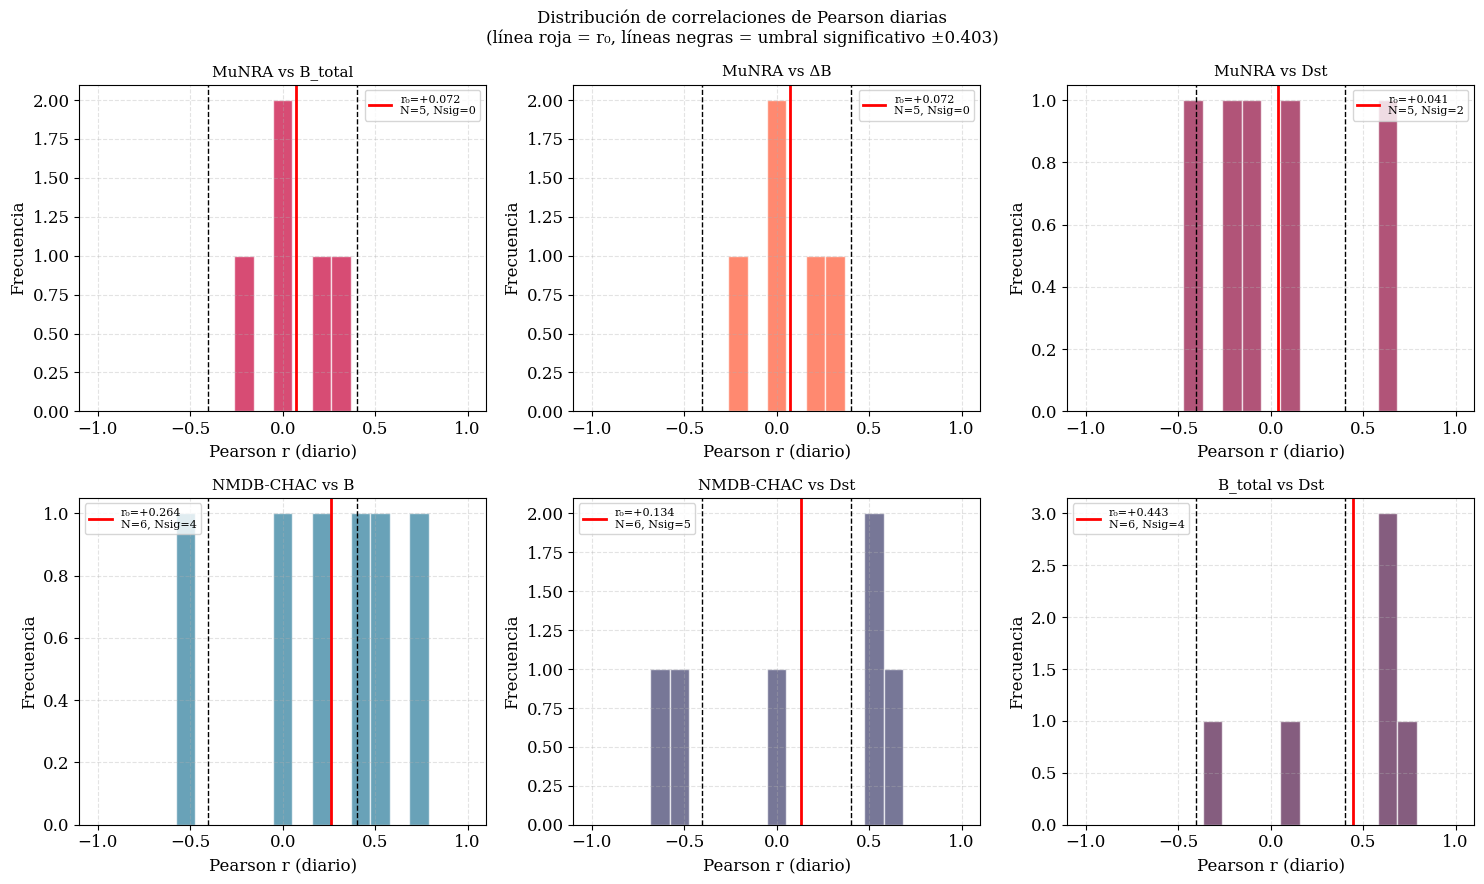

In [ ]:
# ── Histogramas de r diario con distribución de Fisher ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

all_pairs = [
    (df1, 'rate_corr',  'B_total_nT', 'MuNRA vs B_total', '#c70039'),
    (df1, 'rate_corr',  'delta_B_nT', 'MuNRA vs ΔB',      '#ff5733'),
    (df1, 'rate_corr',  'Dst',        'MuNRA vs Dst',      '#900c3f'),
    (df2, 'MXCO_cpm',   'B_total_nT', 'NMDB-MXCO vs B',   '#2a7b9b'),
    (df2, 'MXCO_cpm',   'Dst',        'NMDB-MXCO vs Dst',  '#3d3d6b'),
    (df2, 'B_total_nT', 'Dst',        'B_total vs Dst',    '#511849'),
]

for ax, (df_use, ca, cb, title, color) in zip(axes, all_pairs):
    r_d = pearson_daily(df_use[ca], df_use[cb])
    if len(r_d) == 0:
        ax.set_title(title + '\n(sin datos)')
        continue

    fs = fisher_r0(r_d)
    bins = np.linspace(-1, 1, 20)
    ax.hist(r_d.values, bins=bins, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(R_THRESHOLD,  color='black', ls='--', lw=1)
    ax.axvline(-R_THRESHOLD, color='black', ls='--', lw=1)
    ax.axvline(fs['r0'], color='red', lw=2,
               label=f'r₀={fs["r0"]:+.3f}\nN={fs["N"]}, Nsig={fs["N_sig"]}')
    ax.set_xlabel('Pearson r (diario)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Distribución de correlaciones de Pearson diarias\n'
             '(línea roja = r₀, líneas negras = umbral significativo ±0.403)',
             fontsize=12)
plt.tight_layout()
plt.savefig('Fig3_Histogramas_Pearson.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlación cruzada con retardo temporal

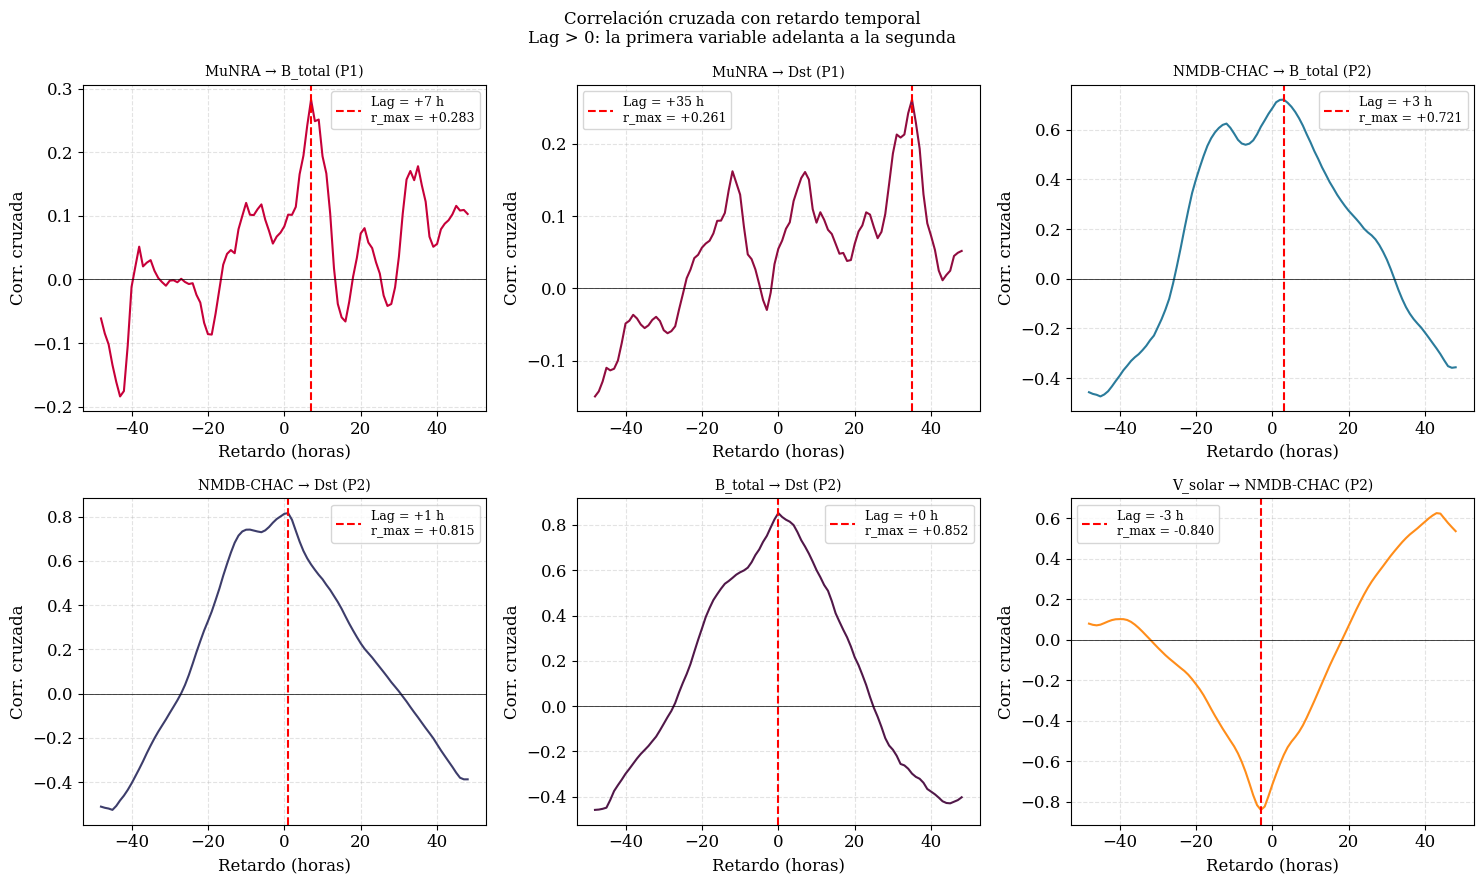

                     Par  Lag ópt. (h)   r_max
    MuNRA → B_total (P1)             7 +0.2829
        MuNRA → Dst (P1)            35 +0.2612
NMDB-CHAC → B_total (P2)             3 +0.7209
    NMDB-CHAC → Dst (P2)             1 +0.8154
      B_total → Dst (P2)             0 +0.8524
V_solar → NMDB-CHAC (P2)            -3 -0.8398


In [ ]:
def cross_corr_lag(s1, s2, max_lag_h=48):
    """
    Correlación cruzada normalizada entre dos series horarias.
    Retorna (lags_h, cc, lag_optimo_h, r_max).
    Lag positivo: s2 va DESPUÉS de s1 (s1 adelanta a s2).
    """
    # Alinear en índice común
    common = s1.index.intersection(s2.index)
    a = s1.reindex(common).interpolate(limit=6).fillna(s1.mean())
    b = s2.reindex(common).interpolate(limit=6).fillna(s2.mean())
    n = len(a)
    if n < 10:
        return np.array([0]), np.array([0]), 0, 0

    an = (a - a.mean()) / a.std()
    bn = (b - b.mean()) / b.std()
    cc   = correlate(an, bn, mode='full') / n
    lags = np.arange(-(n - 1), n)       # en muestras horarias
    mask = np.abs(lags) <= max_lag_h
    lags_h, cc_m = lags[mask], cc[mask]
    lag_opt = lags_h[np.argmax(np.abs(cc_m))]
    r_max   = cc_m[np.argmax(np.abs(cc_m))]
    return lags_h, cc_m, int(lag_opt), float(r_max)


# ── Pares de cross-correlación ────────────────────────────────────────────────
cc_pairs = [
    # (dataset, col_A,       col_B,       título,                color)
    (df1, 'rate_corr',  'B_total_nT', 'MuNRA → B_total (P1)',   '#c70039'),
    (df1, 'rate_corr',  'Dst',        'MuNRA → Dst (P1)',        '#900c3f'),
    (df2, 'MXCO_cpm',   'B_total_nT', 'NMDB-MXCO → B_total (P2)','#2a7b9b'),
    (df2, 'MXCO_cpm',   'Dst',        'NMDB-MXCO → Dst (P2)',    '#3d3d6b'),
    (df2, 'B_total_nT', 'Dst',        'B_total → Dst (P2)',      '#511849'),
    (df2, 'speed',      'MXCO_cpm',   'V_solar → NMDB-MXCO (P2)','#ff8d1a'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

cc_results = []
for ax, (df_use, ca, cb, title, color) in zip(axes, cc_pairs):
    if ca not in df_use.columns or cb not in df_use.columns:
        ax.set_title(title + '\n(sin datos)')
        continue
    lags, cc, lag_opt, r_max = cross_corr_lag(df_use[ca], df_use[cb])

    ax.plot(lags, cc, color=color, lw=1.5)
    ax.axvline(lag_opt, color='red', ls='--', lw=1.5,
               label=f'Lag = {lag_opt:+d} h\nr_max = {r_max:+.3f}')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Retardo (horas)')
    ax.set_ylabel('Corr. cruzada')
    ax.legend(fontsize=9)

    cc_results.append({
        'Par':         title,
        'Lag ópt. (h)': lag_opt,
        'r_max':       f'{r_max:+.4f}',
    })

plt.suptitle('Correlación cruzada con retardo temporal\n'
             'Lag > 0: la primera variable adelanta a la segunda', fontsize=12)
plt.tight_layout()
plt.savefig('Fig4_CrossCorrelacion_Lag.png', dpi=150, bbox_inches='tight')
plt.show()

print(pd.DataFrame(cc_results).to_string(index=False))

## 7. Tabla resumen final

In [ ]:
# ── Tabla unificada con todas las métricas de correlación ────────────────────
summary_rows = []

all_analysis = [
    # (dataset,  col_A,       col_B,       etiqueta_par,              período)
    (df1, 'rate_corr',  'B_total_nT', 'MuNRA vs B_total (EZIE)',   'Jan 9–16'),
    (df1, 'rate_corr',  'delta_B_nT', 'MuNRA vs ΔB (EZIE)',        'Jan 9–16'),
    (df1, 'rate_corr',  'Dst',        'MuNRA vs Dst',               'Jan 9–16'),
    (df1, 'rate_corr',  'pressure_Pa','MuNRA vs Presión (β)',       'Jan 9–16'),
    (df2, 'MXCO_cpm',   'B_total_nT', 'NMDB-MXCO vs B_total',      'Jan 18–23'),
    (df2, 'MXCO_cpm',   'Dst',        'NMDB-MXCO vs Dst',           'Jan 18–23'),
    (df2, 'B_total_nT', 'Dst',        'B_total (EZIE) vs Dst',      'Jan 18–23'),
]

for df_use, ca, cb, label, periodo in all_analysis:
    if ca not in df_use.columns or cb not in df_use.columns:
        continue
    sub = df_use[[ca, cb]].dropna()
    if len(sub) < 5:
        continue
    r_g, p_g  = pearsonr(sub[ca], sub[cb])
    r_d       = pearson_daily(df_use[ca], df_use[cb])
    fs        = fisher_r0(r_d) if len(r_d) > 0 else {'r0': np.nan, 'N': 0, 'N_sig': 0}
    _, _, lag, rmax = cross_corr_lag(df_use[ca], df_use[cb])

    summary_rows.append({
        'Período':      periodo,
        'Par':          label,
        'N pts':        len(sub),
        'r global':     f'{r_g:+.4f}',
        'p-value':      f'{p_g:.2e}',
        '|r|≥0.403':   '✓' if abs(r_g) >= R_THRESHOLD else '✗',
        'r₀ Fisher':   f'{fs["r0"]:+.4f}' if not np.isnan(fs['r0']) else 'n/a',
        'Nsig/Ndías':  f'{fs["N_sig"]}/{fs["N"]}',
        'Lag (h)':      f'{lag:+d}',
        'r_max(lag)':   f'{rmax:+.4f}',
    })

df_summary = pd.DataFrame(summary_rows)
print('TABLA RESUMEN DE CORRELACIONES — RETO 14')
print('=' * 80)
display(df_summary)
df_summary.to_csv('Correlaciones_Resumen.csv', index=False)
print('\nGuardado en Correlaciones_Resumen.csv')

TABLA RESUMEN DE CORRELACIONES — RETO 14


,Período,Par,N pts,r global,p-value,|r|≥0.403,r₀ Fisher,Nsig/Ndías,Lag (h),r_max(lag)
0,Jan 9–16,MuNRA vs B_total (EZIE),124,+0.1250,1.66e-01,✗,+0.0718,0/5,+7,+0.2829
1,Jan 9–16,MuNRA vs ΔB (EZIE),124,+0.1250,1.66e-01,✗,+0.0718,0/5,+7,+0.2829
2,Jan 9–16,MuNRA vs Dst,124,+0.0887,3.27e-01,✗,+0.0414,2/5,+35,+0.2612
3,Jan 9–16,MuNRA vs Presión (β),124,+0.1635,6.97e-02,✗,+0.1870,1/5,-20,-0.2782
4,Jan 18–23,NMDB-CHAC vs B_total,144,+0.6913,8.73e-22,✓,+0.2637,4/6,+3,+0.7209
5,Jan 18–23,NMDB-CHAC vs Dst,144,+0.8178,6.86e-36,✓,+0.1335,5/6,+1,+0.8154
6,Jan 18–23,NMDB-MXCO vs Dst,121,+0.8047,1.02e-28,✓,+0.0146,4/5,-10,+0.7348
7,Jan 18–23,B_total (EZIE) vs Dst,144,+0.8584,5.33e-43,✓,+0.4434,4/6,+0,+0.8524



Guardado en Correlaciones_Resumen.csv


## Notas de interpretación

### Física esperada
| Correlación | Signo esperado | Razón física |
|---|---|---|
| Rayos cósmicos vs Dst | **positivo** | Ambos disminuyen durante la tormenta (FD heliocéntrico + corriente de anillo); la correlación es indirecta — ambas variables responden al mismo evento solar |
| Rayos cósmicos vs B_total (local) | **ambiguo** | Efectos competidores: (1) corriente de anillo reduce B en la ecuatorial → umbral de rigidez cae → más RC llegan (positivo con B_total); (2) FD heliocéntrico reduce el flujo de RC (negativo con B_total durante fase principal). El signo neto depende de la latitud del detector y de cuál efecto domina |
| Rayos cósmicos vs Presión | **negativo** | Mayor presión → más masa atmosférica → mayor absorción de partículas secundarias |
| B_total (local) vs Dst | **positivo** | SSC: magnetopausa comprimida → B_local y Dst aumentan juntos; fase principal: corriente de anillo crea campo opuesto al dipolo ecuatorial → B_local y Dst caen juntos |

### Retardo temporal
- **Lag V_solar (L1) → Dst**: el viento solar medido en L1 llega a la magnetopausa en ~30–60 min; el tiempo adicional de formación de la corriente de anillo es de varias horas. El lag total observado entre V_solar (OMNI/L1) y el mínimo de Dst suele ser **2–8 h**.
- **Tiempo de tránsito CME Sol → 1 AU**: a 1125 km/s, t = 1.496×10⁸ km / 1125 km/s ≈ **37 h**. Para cubrir 1 AU en 19 h se necesitaría ~2190 km/s. No confundir este tiempo de tránsito con el lag L1→Dst, que es mucho menor.
- **Lag Dst → B_total local**: < 1 h; ambos responden casi simultáneamente a la variación de la corriente de anillo.

### Decremento Forbush esperado
Para una tormenta de Dst_mín ≈ −236 nT la amplitud del FD es típicamente **5–15 %** en monitores de neutrones de altitud media-alta (Ciudad de México/MXCO).
